# Лабораторная работа №2

## Вариационные автокодировщики для моделирования спроса на велосипеды в Сеуле

В этой работе моделируется почасовой спрос на прокат велосипедов в Сеуле. Целевая переменная — `rented_bike_count`, то есть количество арендованных велосипедов за час.

Задача формулируется как условная генеративная реконструкция временных окон:

$$
p(\text{rented\_bike\_count window} \mid \text{weather, calendar, operation window})
$$

Модель не прогнозирует будущие часы по прошлым. Она восстанавливает уже наблюдаемое окно целевого ряда при известных условных признаках того же временного интервала. Такой подход позволяет сравнить две формы латентного представления:

- `Conditional VAE` с непрерывным гауссовским латентным пространством;
- `Conditional VQ-VAE` с дискретной кодовой книгой.

## Методологическая схема

Один обучающий пример — это скользящее окно фиксированной длины. Внутри окна все признаки берутся за одни и те же 32 часа, но реконструируется только целевой ряд спроса. Остальные признаки используются как условие: погода, время суток, выходные и праздники, сезон и статус работы сервиса.

Основные этапы:

1. хронологическое разбиение на train, validation и test;
2. масштабирование непрерывных признаков только после разбиения;
3. построение скользящих окон отдельно внутри каждого split;
4. обучение `Conditional VAE`;
5. эксперимент с разными значениями `beta`;
6. обучение `Conditional VQ-VAE`;
7. анализ использования кодовой книги;
8. склейка перекрывающихся окон через overlap-add.

In [127]:
import math
import random
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)

In [128]:
CONFIG = {
    "data": {
        "path": "data/processed.csv",
        "time_col": "datetime",
        "target": "rented_bike_count",
        "features": [
            "temperature_c",
            "humidity_pct",
            "wind_speed_mps",
            "visibility_10m",
            "solar_radiation_mj_m2",
            "rainfall_mm",
            "snowfall_cm",
            "hour_sin",
            "hour_cos",
            "is_weekend",
            "is_holiday",
            "functioning_day",
            "season_winter",
            "season_spring",
            "season_summer",
            "season_autumn",
            "rented_bike_count",
        ],
        "continuous_features": [
            "temperature_c",
            "humidity_pct",
            "wind_speed_mps",
            "visibility_10m",
            "solar_radiation_mj_m2",
            "rainfall_mm",
            "snowfall_cm",
            "rented_bike_count",
        ],
    },
    "split": {
        "train_ratio": 0.70,
        "val_ratio": 0.15,
    },
    "window": {
        "size": 32,
        "stride": 1,
    },
    "loader": {
        "batch_size": 128,
    },
    "cvae": {
        "latent_dim": 8,
        "hidden_dims": (256, 128, 64),
        "lr": 3e-4,
        "epochs": 200,
        "beta_max": 0.02,
        "warmup_epochs": 20,
    },
    "beta_experiment": {
        "values": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
        "epochs": 200,
    },
    "vqvae": {
        "num_embeddings": 32,
        "embedding_dim": 8,
        "num_latent_tokens": 4,
        "commitment_beta": 0.25,
        "hidden_dims": (256, 128, 64),
        "lr": 1e-3,
        "epochs": 200,
    },
    "plots": {
        "seed": 42,
        "num_examples": 6,
        "fragment_len": 240,
    },
    "seed": 42,
}

# все ключевые индексы считаются из CONFIG, без ручных чисел
FEATURES = CONFIG["data"]["features"]
TARGET = CONFIG["data"]["target"]
TIME_COL = CONFIG["data"]["time_col"]
CONTINUOUS_FEATURES = CONFIG["data"]["continuous_features"]
WINDOW_SIZE = CONFIG["window"]["size"]
BATCH_SIZE = CONFIG["loader"]["batch_size"]

# индексы цели и условий зависят только от порядка FEATURES
TARGET_IDX = FEATURES.index(TARGET)
COND_IDX = [i for i, name in enumerate(FEATURES) if name != TARGET]
CONT_IDX = [FEATURES.index(name) for name in CONTINUOUS_FEATURES]
TARGET_POS_IN_SCALER = CONTINUOUS_FEATURES.index(TARGET)

# цель не должна попасть в условные признаки
assert TARGET_IDX not in COND_IDX
assert FEATURES[-1] == TARGET

print("Целевой признак:", TARGET)
print("Число признаков:", len(FEATURES))
print("Число условных признаков:", len(COND_IDX))
print("Размер окна:", WINDOW_SIZE)

Целевой признак: rented_bike_count
Число признаков: 17
Число условных признаков: 16
Размер окна: 32


In [129]:
def set_seed(seed: int) -> None:
    """Фиксирует seed для Python, NumPy и PyTorch, чтобы результаты обучения были воспроизводимыми"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(CONFIG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", device)

Используемое устройство: cpu


## Загрузка подготовленного набора данных

Используется файл `data/processed.csv`. В нем уже выполнены базовые операции подготовки: собран почасовой timestamp, переименованы признаки, закодированы календарные и сезонные признаки, сохранена регулярная почасовая сетка.

In [130]:
project_root = Path.cwd()
if not (project_root / CONFIG["data"]["path"]).exists():
    project_root = project_root.parent

data_path = project_root / CONFIG["data"]["path"]
# читаем уже подготовленный файл, без повторной очистки raw CSV
df = pd.read_csv(data_path)
# timestamp задает порядок для split, окон и графиков
df[TIME_COL] = pd.to_datetime(df[TIME_COL])
df = df.sort_values(TIME_COL).reset_index(drop=True)

# проверяем контракт подготовленного набора признаков
missing_columns = sorted(set([TIME_COL] + FEATURES) - set(df.columns))
if missing_columns:
    raise ValueError(f"В данных отсутствуют столбцы: {missing_columns}")

# оставляем только время и признаки, участвующие в моделировании
df = df[[TIME_COL] + FEATURES].copy()
display(df.head())
print("Размер данных:", df.shape)
print("Период:", df[TIME_COL].min(), "->", df[TIME_COL].max())

,datetime,temperature_c,humidity_pct,wind_speed_mps,visibility_10m,solar_radiation_mj_m2,rainfall_mm,snowfall_cm,hour_sin,hour_cos,is_weekend,is_holiday,functioning_day,season_winter,season_spring,season_summer,season_autumn,rented_bike_count
0,2017-12-01 00:00:00,-5.2,37.0,2.2,2000.0,0.0,0.0,0.0,0.000000,1.000000,0.0,0.0,1.0,1.0,0.0,0.0,0.0,254.0
1,2017-12-01 01:00:00,-5.5,38.0,0.8,2000.0,0.0,0.0,0.0,0.258819,0.965926,0.0,0.0,1.0,1.0,0.0,0.0,0.0,204.0
2,2017-12-01 02:00:00,-6.0,39.0,1.0,2000.0,0.0,0.0,0.0,0.500000,0.866025,0.0,0.0,1.0,1.0,0.0,0.0,0.0,173.0
3,2017-12-01 03:00:00,-6.2,40.0,0.9,2000.0,0.0,0.0,0.0,0.707107,0.707107,0.0,0.0,1.0,1.0,0.0,0.0,0.0,107.0
4,2017-12-01 04:00:00,-6.0,36.0,2.3,2000.0,0.0,0.0,0.0,0.866025,0.500000,0.0,0.0,1.0,1.0,0.0,0.0,0.0,78.0


Размер данных: (8760, 18)
Период: 2017-12-01 00:00:00 -> 2018-11-30 23:00:00


In [131]:
# постоянный шаг нужен для корректных окон фиксированной длины
time_diffs = df[TIME_COL].diff().dropna()
duplicate_times = df[TIME_COL].duplicated().sum()
missing_values = int(df.isna().sum().sum())

print("Пропущенные значения:", missing_values)
print("Дубликаты времени:", duplicate_times)
print("Уникальные интервалы между строками:")
display(time_diffs.value_counts().head())

expected_hours = int((df[TIME_COL].max() - df[TIME_COL].min()).total_seconds() // 3600) + 1
print("Ожидаемое число часов:", expected_hours)
print("Фактическое число строк:", len(df))

Пропущенные значения: 0
Дубликаты времени: 0
Уникальные интервалы между строками:


datetime
0 days 01:00:00    8759
Name: count, dtype: int64

Ожидаемое число часов: 8760
Фактическое число строк: 8760


Проверка показывает, что ряд можно использовать для фиксированных окон без ресэмплинга: строки идут по времени, timestamp не дублируется, а временной шаг соответствует одному часу. Это важно, потому что скользящее окно в дальнейшем создается по порядку строк.

In [132]:
summary_cols = [TARGET, "temperature_c", "humidity_pct", "rainfall_mm", "snowfall_cm", "functioning_day"]
display(df[summary_cols].describe().T)

print("Часы с неработающим сервисом:", int((df["functioning_day"] == 0).sum()))
print("Нулевой спрос:", int((df[TARGET] == 0).sum()))

,count,mean,std,min,25%,50%,75%,max
rented_bike_count,8760.0,704.602055,644.997468,0.0,191.0,504.5,1065.25,3556.0
temperature_c,8760.0,12.882922,11.944825,-17.8,3.5,13.7,22.50,39.4
humidity_pct,8760.0,58.226256,20.362413,0.0,42.0,57.0,74.00,98.0
rainfall_mm,8760.0,0.148687,1.128193,0.0,0.0,0.0,0.00,35.0
snowfall_cm,8760.0,0.075068,0.436746,0.0,0.0,0.0,0.00,8.8
functioning_day,8760.0,0.966324,0.180404,0.0,1.0,1.0,1.00,1.0


Часы с неработающим сервисом: 295
Нулевой спрос: 295


Сводка показывает сильную асимметрию спроса: медиана заметно ниже максимума, а нулевые значения совпадают с часами, когда сервис не работал. Поэтому `functioning_day` важен как условный признак, иначе модель будет воспринимать закрытия как обычные низкие значения спроса

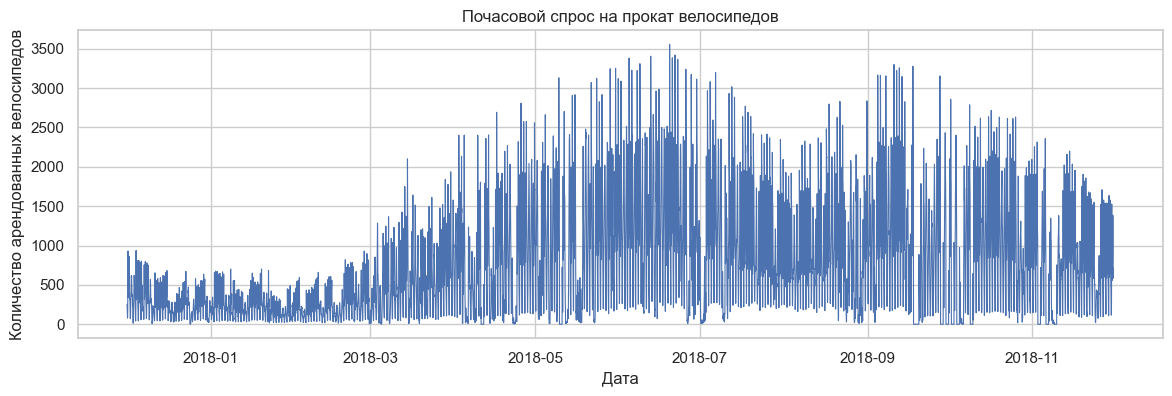

In [133]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df[TIME_COL], df[TARGET], linewidth=0.8)
ax.set_title("Почасовой спрос на прокат велосипедов")
ax.set_xlabel("Дата")
ax.set_ylabel("Количество арендованных велосипедов")
plt.show()

На полном временном ряду видны сезонные изменения и резкие провалы до нуля. Для этой лабораторной это означает, что модель должна восстанавливать не только гладкие суточные формы, но и режимы с очень низким или отсутствующим спросом

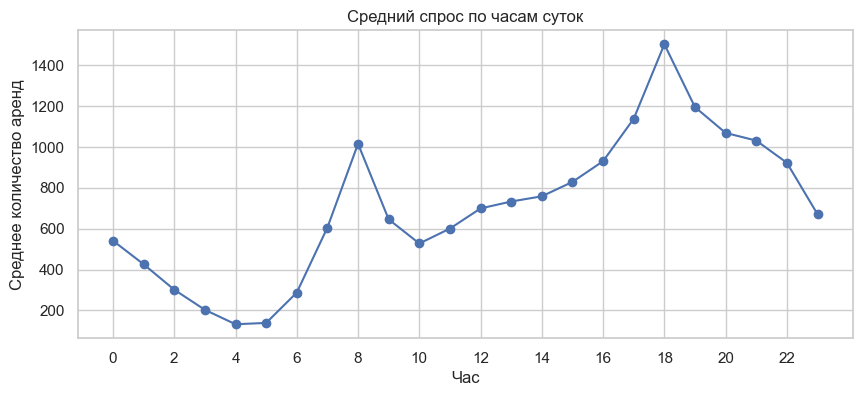

In [134]:
hourly_profile = df.assign(hour=df[TIME_COL].dt.hour).groupby("hour")[TARGET].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hourly_profile.index, hourly_profile.values, marker="o")
ax.set_title("Средний спрос по часам суток")
ax.set_xlabel("Час")
ax.set_ylabel("Среднее количество аренд")
ax.set_xticks(range(0, 24, 2))
plt.show()

Средний профиль по часам подтверждает выраженную суточную структуру: минимальный спрос приходится на раннее утро, а максимум — на вечерний час пик. Поэтому циклические признаки `hour_sin` и `hour_cos` действительно несут полезный контекст для условной реконструкции

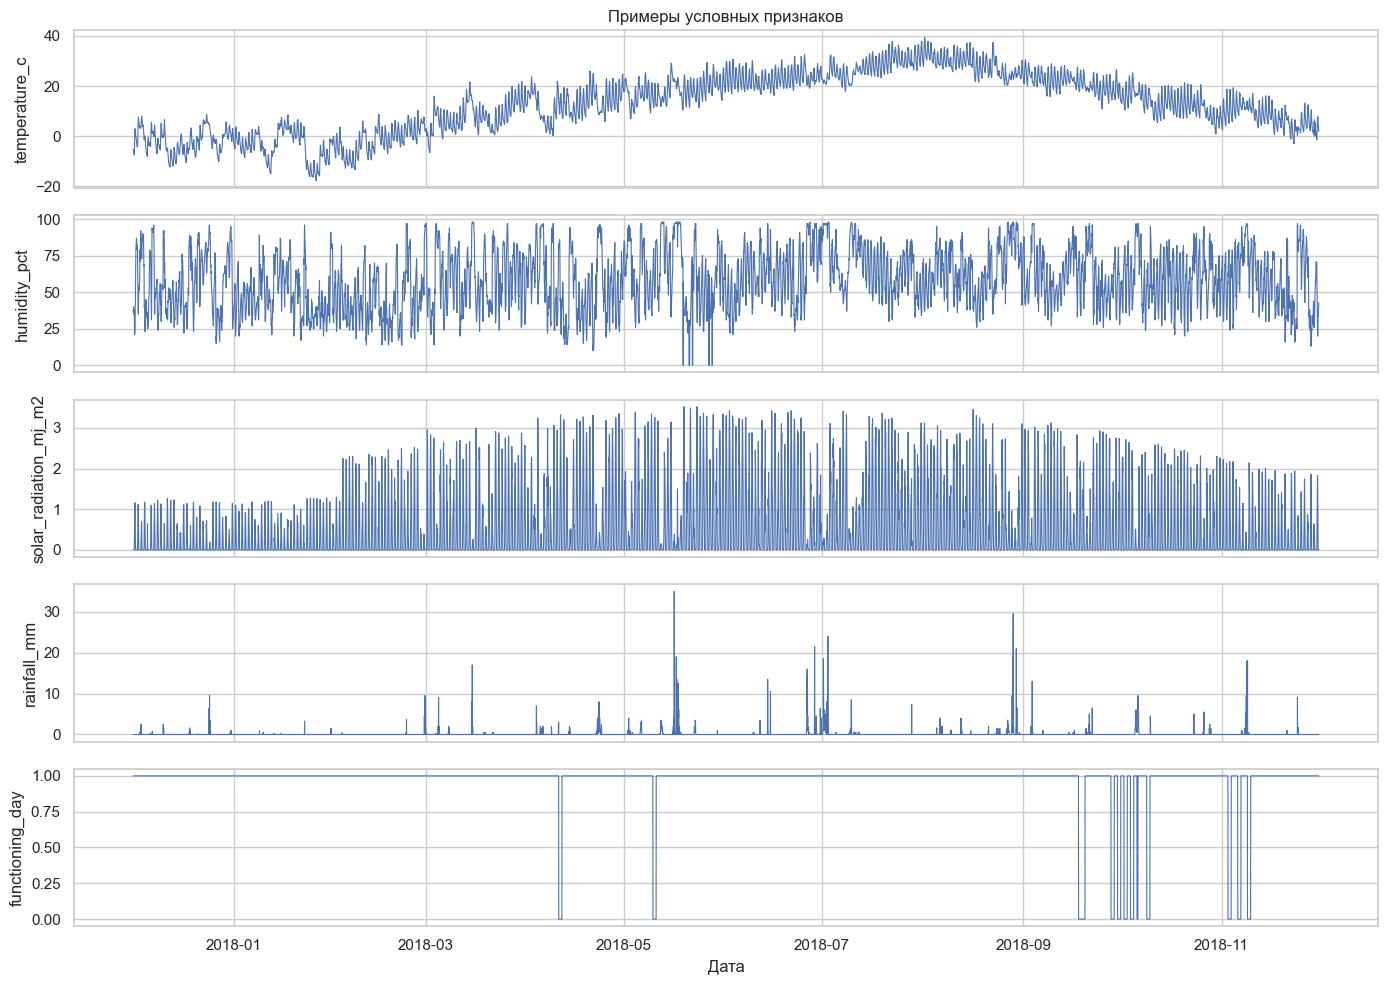

In [135]:
condition_plot_cols = [
    "temperature_c",
    "humidity_pct",
    "solar_radiation_mj_m2",
    "rainfall_mm",
    "functioning_day",
]

fig, axes = plt.subplots(len(condition_plot_cols), 1, figsize=(14, 10), sharex=True)
for ax, col in zip(axes, condition_plot_cols):
    ax.plot(df[TIME_COL], df[col], linewidth=0.8)
    ax.set_ylabel(col)
axes[0].set_title("Примеры условных признаков")
axes[-1].set_xlabel("Дата")
plt.tight_layout()
plt.show()

Условные признаки описывают разные типы внешнего контекста: непрерывную погоду, осадки и режим работы сервиса. Эти признаки не генерируются моделью, а задают условия, при которых восстанавливается окно спроса

Целевой ряд имеет выраженную суточную структуру, сезонность и периоды нулевого спроса. Поэтому условные признаки выбраны так, чтобы описывать погоду, время суток, выходные и праздники, сезон и факт работы сервиса. В моделях эти признаки не реконструируются: они задают контекст для восстановления окна спроса.

## Хронологическое разбиение и масштабирование

Временные ряды нельзя случайно перемешивать перед split: соседние окна сильно пересекаются, и случайное разбиение привело бы к утечке похожих фрагментов между train и test. Поэтому сначала используется хронологическое разбиение, затем `StandardScaler` обучается только на train-части.

In [136]:
# модель получает числовые признаки; время хранится отдельно
values = df[FEATURES].astype(np.float32).to_numpy()
dates = df[TIME_COL].to_numpy()

# split выполняется срезами по времени, без перемешивания
n_total = len(values)
train_end = int(CONFIG["split"]["train_ratio"] * n_total)
val_end = int((CONFIG["split"]["train_ratio"] + CONFIG["split"]["val_ratio"]) * n_total)

X_train_raw = values[:train_end]
X_val_raw = values[train_end:val_end]
X_test_raw = values[val_end:]

# даты для интерпретации, графиков и склейки
dates_train = dates[:train_end]
dates_val = dates[train_end:val_end]
dates_test = dates[val_end:]

print("Train:", X_train_raw.shape, dates_train[0], "->", dates_train[-1])
print("Validation:", X_val_raw.shape, dates_val[0], "->", dates_val[-1])
print("Test:", X_test_raw.shape, dates_test[0], "->", dates_test[-1])

Train: (6132, 17) 2017-12-01T00:00:00.000000000 -> 2018-08-13T11:00:00.000000000
Validation: (1314, 17) 2018-08-13T12:00:00.000000000 -> 2018-10-07T05:00:00.000000000
Test: (1314, 17) 2018-10-07T06:00:00.000000000 -> 2018-11-30T23:00:00.000000000


In [137]:
scaler = StandardScaler()

# работаем с копиями, чтобы сохранить raw-массивы без изменений
X_train = X_train_raw.copy()
X_val = X_val_raw.copy()
X_test = X_test_raw.copy()

# масштабируем только непрерывные признаки и только после split
X_train[:, CONT_IDX] = scaler.fit_transform(X_train_raw[:, CONT_IDX])
# validation и test используют только train-fitted scaler
X_val[:, CONT_IDX] = scaler.transform(X_val_raw[:, CONT_IDX])
X_test[:, CONT_IDX] = scaler.transform(X_test_raw[:, CONT_IDX])

print("Масштабированные признаки:", CONTINUOUS_FEATURES)
print("Немасштабированные признаки:", [name for name in FEATURES if name not in CONTINUOUS_FEATURES])

Масштабированные признаки: ['temperature_c', 'humidity_pct', 'wind_speed_mps', 'visibility_10m', 'solar_radiation_mj_m2', 'rainfall_mm', 'snowfall_cm', 'rented_bike_count']
Немасштабированные признаки: ['hour_sin', 'hour_cos', 'is_weekend', 'is_holiday', 'functioning_day', 'season_winter', 'season_spring', 'season_summer', 'season_autumn']


In [138]:
def inverse_scale_target(x: np.ndarray) -> np.ndarray:
    """Возвращает масштабированные значения целевого признака в исходную шкалу количества аренд"""
    arr = np.asarray(x)
    flat = arr.reshape(-1)
    # StandardScaler ожидает полный набор continuous-признаков
    buffer = np.zeros((flat.shape[0], len(CONTINUOUS_FEATURES)), dtype=np.float32)
    buffer[:, TARGET_POS_IN_SCALER] = flat
    # после inverse_transform забираем только целевую колонку
    restored = scaler.inverse_transform(buffer)[:, TARGET_POS_IN_SCALER]
    return restored.reshape(arr.shape)

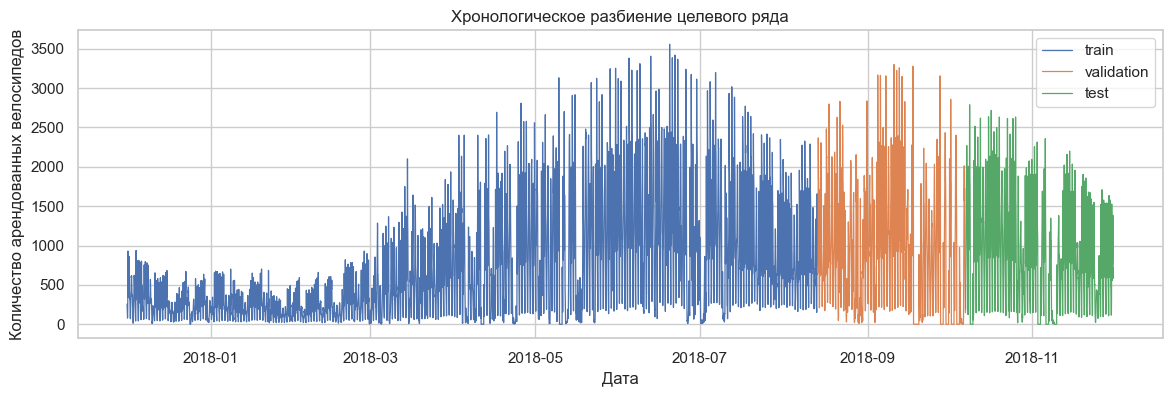

In [139]:
def plot_split_target() -> None:
    """Строит график целевого ряда после хронологического разбиения на train, validation и test"""
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(dates_train, inverse_scale_target(X_train[:, TARGET_IDX]), label="train", linewidth=0.9)
    ax.plot(dates_val, inverse_scale_target(X_val[:, TARGET_IDX]), label="validation", linewidth=0.9)
    ax.plot(dates_test, inverse_scale_target(X_test[:, TARGET_IDX]), label="test", linewidth=0.9)
    ax.set_title("Хронологическое разбиение целевого ряда")
    ax.set_xlabel("Дата")
    ax.set_ylabel("Количество арендованных велосипедов")
    ax.legend()
    plt.show()


plot_split_target()

Разбиение сохраняет порядок времени: train охватывает начало года до середины августа, validation — позднее лето и начало осени, test — октябрь и ноябрь. Это строже случайного split, потому что будущие фрагменты не попадают в обучение через перекрывающиеся окна

Масштабирование выполняется после разбиения, поэтому статистики validation и test не используются при обучении scaler. Бинарные и one-hot признаки оставлены в исходной шкале, потому что они уже имеют ограниченный интервал значений и несут категориальную информацию.

## Скользящие окна

Теперь каждый split превращается в набор перекрывающихся окон длиной 32 часа. Одно окно имеет форму:

```text
[32, 17]
```

Внутри окна последний столбец — `rented_bike_count`, а остальные 16 столбцов — условные признаки. Модели получают все окно целиком, но реконструируют только целевую траекторию длиной 32.

In [140]:
def create_sliding_windows(
    series: np.ndarray,
    window_size: int,
    stride: int = 1,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Создает скользящие окна заданной длины и возвращает сами окна вместе с их позициями в исходном ряду"""
    if len(series) < window_size:
        empty = np.empty((0, window_size, series.shape[1]), dtype=np.float32)
        return empty, np.array([], dtype=int), np.array([], dtype=int)

    # sliding_window_view создает окна как view без лишнего копирования
    raw_windows = np.lib.stride_tricks.sliding_window_view(series, window_size, axis=0)
    # приводим форму к [num_windows, window_size, num_features]
    raw_windows = np.moveaxis(raw_windows, -1, 1)

    # сдвигаем окно на заданный шаг
    windows = raw_windows[::stride]
    starts = np.arange(0, len(series) - window_size + 1, stride)
    # start/end сохраняют привязку окон к исходному ряду
    ends = starts + window_size
    # copy убирает read-only stride view перед передачей в torch
    return np.array(windows, dtype=np.float32, copy=True), starts, ends


def build_window_sets(
    train_series: np.ndarray,
    val_series: np.ndarray,
    test_series: np.ndarray,
    window_size: int,
) -> Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]]:
    """Строит скользящие окна отдельно для train, validation и test, не смешивая временные интервалы"""
    # окна строятся отдельно по split, чтобы не было overlap leakage
    return {
        "train": create_sliding_windows(train_series, window_size, stride=1),
        "val": create_sliding_windows(val_series, window_size, stride=1),
        "test": create_sliding_windows(test_series, window_size, stride=1),
        "test_non_overlap": create_sliding_windows(test_series, window_size, stride=window_size),
    }

In [141]:
# train/val/test окна не пересекают границы split
window_sets = build_window_sets(X_train, X_val, X_test, WINDOW_SIZE)

train_windows, train_starts, train_ends = window_sets["train"]
val_windows, val_starts, val_ends = window_sets["val"]
test_windows, test_starts, test_ends = window_sets["test"]
test_windows_non_overlap, _, _ = window_sets["test_non_overlap"]

print("Train windows:", train_windows.shape)
print("Validation windows:", val_windows.shape)
print("Test windows:", test_windows.shape)
print("Non-overlap test windows:", test_windows_non_overlap.shape)
print("Форма одного окна:", train_windows[0].shape)

Train windows: (6101, 32, 17)
Validation windows: (1283, 32, 17)
Test windows: (1283, 32, 17)
Non-overlap test windows: (41, 32, 17)
Форма одного окна: (32, 17)


После построения окон получается `6101` обучающее окно, `1283` validation-окон и `1283` test-окон. Каждое окно имеет форму `[32, 17]`: 32 часа и 17 признаков, из которых один является целевым спросом

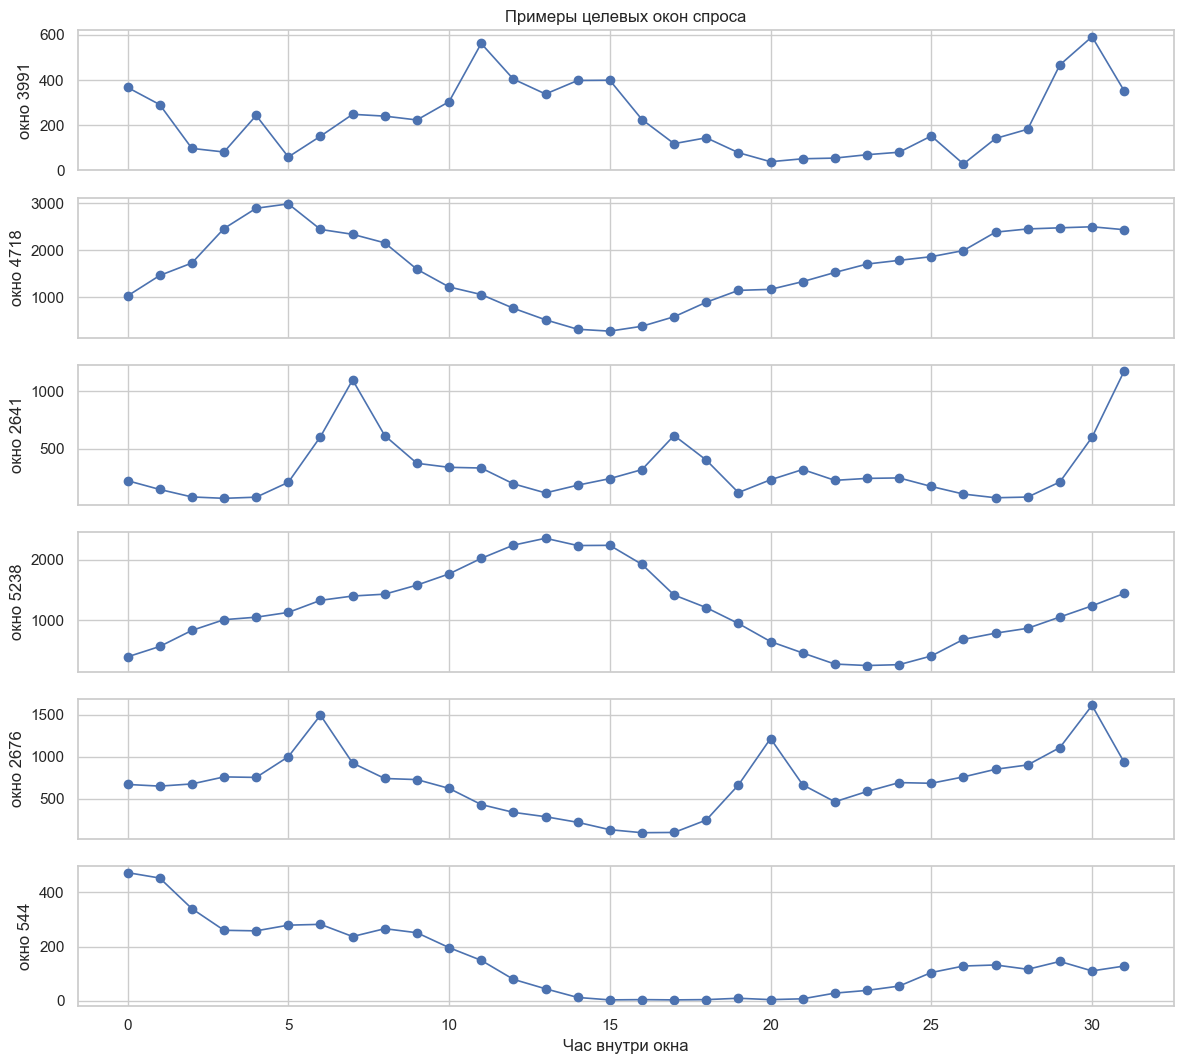

In [142]:
def plot_sample_target_windows(windows: np.ndarray, n_examples: int = 6) -> None:
    """Показывает несколько примеров целевых окон в исходной шкале спроса"""
    rng = np.random.default_rng(CONFIG["plots"]["seed"])
    indices = rng.choice(len(windows), size=min(n_examples, len(windows)), replace=False)

    fig, axes = plt.subplots(len(indices), 1, figsize=(12, 1.8 * len(indices)), sharex=True)
    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        target_window = inverse_scale_target(windows[idx, :, TARGET_IDX])
        ax.plot(target_window, marker="o", linewidth=1.2)
        ax.set_ylabel(f"окно {idx}")

    axes[-1].set_xlabel("Час внутри окна")
    axes[0].set_title("Примеры целевых окон спроса")
    plt.tight_layout()
    plt.show()


plot_sample_target_windows(train_windows)

Окна перекрываются с шагом 1 час. Это увеличивает количество обучающих примеров и сохраняет локальную форму ряда, но означает, что одна и та же временная точка встречается в нескольких окнах. Поэтому в конце понадобится отдельная склейка реконструкций.

## PyTorch DataLoader

В `DataLoader` передается только полный тензор окна. Отделение цели от условий выполняется внутри моделей, чтобы одна и та же подготовка данных подходила и для CVAE, и для VQ-VAE.

In [143]:
def windows_to_tensor(windows: np.ndarray) -> torch.Tensor:
    """Преобразует массив окон в float32 Tensor с явной копией данных"""
    # copy защищает от незаписываемого представления NumPy, которое может возникнуть после оконной обработки
    return torch.from_numpy(np.array(windows, dtype=np.float32, copy=True))


def build_loaders(
    train_windows: np.ndarray,
    val_windows: np.ndarray,
    test_windows: np.ndarray,
    batch_size: int,
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """Создает DataLoader для train, validation и test окон с перемешиванием только обучающей выборки"""
    train_ds = TensorDataset(windows_to_tensor(train_windows))
    val_ds = TensorDataset(windows_to_tensor(val_windows))
    test_ds = TensorDataset(windows_to_tensor(test_windows))

    # перемешиваем только train; val/test сохраняют временной порядок
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = build_loaders(
    train_windows,
    val_windows,
    test_windows,
    BATCH_SIZE,
)

In [144]:
batch = next(iter(train_loader))[0]
print("Batch shape:", batch.shape)
print("Target shape:", batch[..., TARGET_IDX].shape)
print("Condition shape:", batch[..., COND_IDX].shape)

Batch shape: torch.Size([128, 32, 17])
Target shape: torch.Size([128, 32])
Condition shape: torch.Size([128, 32, 16])


Форма batch подтверждает условную постановку: модель получает полное окно `[batch, 32, 17]`, но внутри него отдельно выделяются целевой ряд `[batch, 32]` и условные признаки `[batch, 32, 16]`

## Conditional VAE

`Conditional VAE` строит непрерывное латентное представление окна спроса. Энкодер получает целевой ряд вместе с условиями и оценивает параметры распределения:

$$
q_\phi(z \mid x, y) = \mathcal{N}(\mu_\phi(x, y), \sigma_\phi^2(x, y))
$$

Декодер получает латентный вектор `z` и те же условные признаки `y`, после чего реконструирует только окно спроса `x`. KL-дивергенция удерживает аппроксимирующее распределение рядом со стандартным нормальным prior.

In [145]:
class ConditionalVAE(nn.Module):
    def __init__(
        self,
        window_size: int,
        num_features: int,
        target_idx: int,
        latent_dim: int,
        hidden_dims: Tuple[int, ...],
    ) -> None:
        """Инициализирует ConditionalVAE и вычисляет размеры target, condition, encoder и decoder по параметрам окна"""
        super().__init__()
        self.window_size = window_size
        self.num_features = num_features
        self.target_idx = target_idx
        self.cond_idx = [i for i in range(num_features) if i != target_idx]  # все признаки кроме цели
        self.latent_dim = latent_dim

        # окно разворачивается в MLP-вектор target + condition
        self.target_dim = window_size
        self.cond_dim = window_size * (num_features - 1)
        encoder_input_dim = self.target_dim + self.cond_dim

        encoder_layers: List[nn.Module] = []
        prev_dim = encoder_input_dim
        for hidden_dim in hidden_dims:
            encoder_layers.extend([nn.Linear(prev_dim, hidden_dim), nn.ReLU()])
            prev_dim = hidden_dim
        self.encoder = nn.Sequential(*encoder_layers)
        # энкодер задает параметры q(z | x, y), а не сам z
        self.fc_mu = nn.Linear(prev_dim, latent_dim)
        self.fc_logvar = nn.Linear(prev_dim, latent_dim)

        # декодер получает z и то же условие, а выводит только целевое окно
        decoder_layers: List[nn.Module] = []
        prev_dim = latent_dim + self.cond_dim
        for hidden_dim in reversed(hidden_dims):
            decoder_layers.extend([nn.Linear(prev_dim, hidden_dim), nn.ReLU()])
            prev_dim = hidden_dim
        decoder_layers.append(nn.Linear(prev_dim, self.target_dim))
        self.decoder = nn.Sequential(*decoder_layers)

    def split_window(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """Разделяет полное окно на целевой ряд и плоский вектор условных признаков"""
        # отделяем целевой ряд от условных признаков
        target = x[..., self.target_idx]
        condition = x[..., self.cond_idx].reshape(x.size(0), -1)
        return target, condition

    def encode_from_parts(self, target: torch.Tensor, condition: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """Кодирует target и condition в параметры гауссовского posterior распределения"""
        encoded = self.encoder(torch.cat([target, condition], dim=1))
        return self.fc_mu(encoded), self.fc_logvar(encoded)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        """Применяет трюк с репараметризацией для дифференцируемого сэмплирования латентного z"""
        # reparameterization сохраняет дифференцируемость стохастического z
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z: torch.Tensor, condition: torch.Tensor) -> torch.Tensor:
        """Восстанавливает целевое окно из латентного вектора и условных признаков"""
        return self.decoder(torch.cat([z, condition], dim=1))

    def forward(self, x: torch.Tensor, sample: bool = True) -> Dict[str, torch.Tensor]:
        """Выполняет полный проход ConditionalVAE от окна к реконструкции, mu, logvar и condition"""
        target, condition = self.split_window(x)
        mu, logvar = self.encode_from_parts(target, condition)
        # при оценке используем mu, чтобы убрать случайность реконструкции
        z = self.reparameterize(mu, logvar) if sample else mu
        recon = self.decode(z, condition)
        return {
            "recon": recon,
            "target": target,
            "mu": mu,
            "logvar": logvar,
            "condition": condition,
        }

    def sample_prior(self, condition: torch.Tensor) -> torch.Tensor:
        """Генерирует условное целевое окно из стандартного нормального prior при заданном condition"""
        # prior sample все равно условный: контекст не генерируется моделью
        z = torch.randn(condition.size(0), self.latent_dim, device=condition.device)
        return self.decode(z, condition)

In [146]:
def cvae_loss_function(
    recon_target: torch.Tensor,
    target: torch.Tensor,
    mu: torch.Tensor,
    logvar: torch.Tensor,
    beta: float,
) -> Dict[str, torch.Tensor]:
    """Вычисляет total loss для CVAE как сумму reconstruction loss и beta-взвешенной KL-регуляризации"""
    # reconstruction суммируется по 32 часам и усредняется по batch
    recon_loss = F.mse_loss(recon_target, target, reduction="sum") / target.size(0)
    # закрытая форма KL для q(z|x,y) против N(0, I)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / target.size(0)
    # beta задает силу регуляризации латентного пространства
    total_loss = recon_loss + beta * kl_loss
    return {
        "total": total_loss,
        "recon": recon_loss,
        "kl": kl_loss,
    }

In [147]:
def run_cvae_epoch(
    model: ConditionalVAE,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer | None,
    beta: float,
    device: torch.device,
) -> Dict[str, float]:
    """Выполняет одну эпоху обучения или валидации ConditionalVAE и возвращает усредненные компоненты loss"""
    # optimizer=None означает validation/test режим
    is_train = optimizer is not None
    model.train(is_train)
    totals = {"total": 0.0, "recon": 0.0, "kl": 0.0}
    n_samples = 0

    for (x_batch,) in loader:
        x_batch = x_batch.to(device)

        if is_train:
            optimizer.zero_grad()

        # на train используем стохастический z, на eval — детерминированный mu
        outputs = model(x_batch, sample=is_train)
        losses = cvae_loss_function(
            outputs["recon"],
            outputs["target"],
            outputs["mu"],
            outputs["logvar"],
            beta,
        )

        if is_train:
            losses["total"].backward()
            optimizer.step()

        # усредняем статистики по числу окон, а не по числу batch
        batch_size = x_batch.size(0)
        n_samples += batch_size
        for key in totals:
            totals[key] += float(losses[key].detach().cpu()) * batch_size

    return {key: value / n_samples for key, value in totals.items()}

In [148]:
def train_conditional_vae(
    model: ConditionalVAE,
    train_loader: DataLoader,
    val_loader: DataLoader,
    config: Dict,
    device: torch.device,
) -> Dict[str, List[float]]:
    """Обучает ConditionalVAE с beta warmup и сохраняет историю train и validation метрик"""
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
    # история хранит компоненты ELBO отдельно для диагностики
    history = {
        "train_total": [],
        "train_recon": [],
        "train_kl": [],
        "val_total": [],
        "val_recon": [],
        "val_kl": [],
        "beta": [],
    }

    for epoch in range(1, config["epochs"] + 1):
        # beta постепенно усиливает KL-регуляризацию
        beta = config["beta_max"] * min(1.0, epoch / config["warmup_epochs"])
        train_stats = run_cvae_epoch(model, train_loader, optimizer, beta, device)
        val_stats = run_cvae_epoch(model, val_loader, None, beta, device)

        history["train_total"].append(train_stats["total"])
        history["train_recon"].append(train_stats["recon"])
        history["train_kl"].append(train_stats["kl"])
        history["val_total"].append(val_stats["total"])
        history["val_recon"].append(val_stats["recon"])
        history["val_kl"].append(val_stats["kl"])
        history["beta"].append(beta)

        if epoch == 1 or epoch % 10 == 0 or epoch == config["epochs"]:
            print(
                f"Epoch {epoch:03d} | beta={beta:.4f} | "
                f"train={train_stats['total']:.4f} | val={val_stats['total']:.4f} | "
                f"train_recon={train_stats['recon']:.4f} | train_kl={train_stats['kl']:.4f}"
            )

    return history

In [149]:
def plot_cvae_history(history: Dict[str, List[float]]) -> None:
    """Визуализирует динамику total, reconstruction, KL loss и расписание beta для CVAE"""
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))

    axes[0, 0].plot(history["train_total"], label="train")
    axes[0, 0].plot(history["val_total"], label="validation")
    axes[0, 0].set_title("CVAE: total loss")
    axes[0, 0].legend()

    axes[0, 1].plot(history["train_recon"], label="train")
    axes[0, 1].plot(history["val_recon"], label="validation")
    axes[0, 1].set_title("CVAE: reconstruction loss")
    axes[0, 1].legend()

    axes[1, 0].plot(history["train_kl"], label="train")
    axes[1, 0].plot(history["val_kl"], label="validation")
    axes[1, 0].set_title("CVAE: KL loss")
    axes[1, 0].legend()

    axes[1, 1].plot(history["beta"])
    axes[1, 1].set_title("CVAE: beta warmup")

    for ax in axes.ravel():
        ax.set_xlabel("Epoch")
    plt.tight_layout()
    plt.show()

In [150]:
# входные размеры выводятся из Seoul feature setup, не задаются вручную
cvae = ConditionalVAE(
    window_size=WINDOW_SIZE,
    num_features=len(FEATURES),
    target_idx=TARGET_IDX,
    latent_dim=CONFIG["cvae"]["latent_dim"],
    hidden_dims=CONFIG["cvae"]["hidden_dims"],
).to(device)

print(cvae)
print("CVAE encoder input dim:", cvae.target_dim + cvae.cond_dim)
print("CVAE decoder input dim:", cvae.latent_dim + cvae.cond_dim)

cvae_history = train_conditional_vae(
    cvae,
    train_loader,
    val_loader,
    CONFIG["cvae"],
    device,
)

ConditionalVAE(
  (encoder): Sequential(
    (0): Linear(in_features=544, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
  )
  (fc_mu): Linear(in_features=64, out_features=8, bias=True)
  (fc_logvar): Linear(in_features=64, out_features=8, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=520, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=32, bias=True)
  )
)
CVAE encoder input dim: 544
CVAE decoder input dim: 520
Epoch 001 | beta=0.0010 | train=24.4608 | val=27.6754 | train_recon=24.4550 | train_kl=5.7646
Epoch 010 | beta=0.0100 | train=3.5674 | val=10.6606 | train_recon=3.4609 | train_kl=10.6521
Epoch 020 | beta=0.0200 | tra

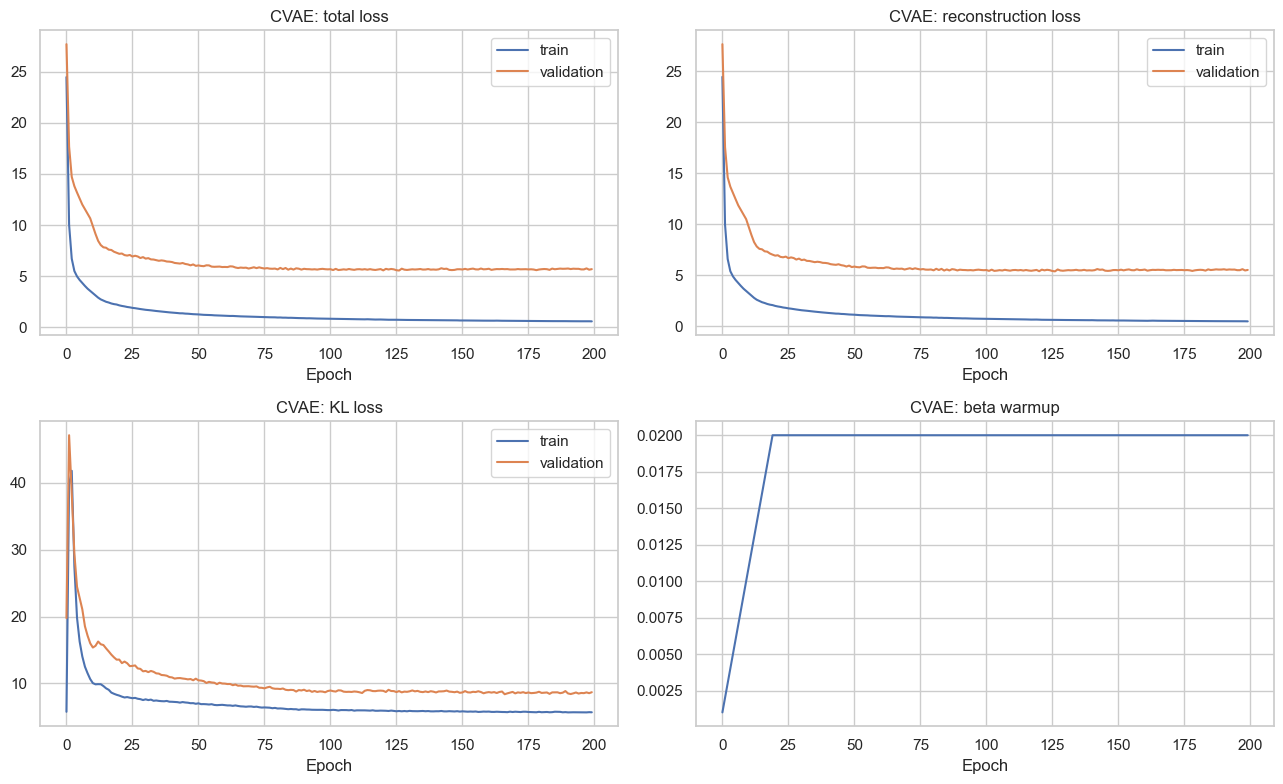

In [151]:
plot_cvae_history(cvae_history)

По истории обучения CVAE нужно смотреть не только на снижение reconstruction loss, но и на поведение KL. Если validation-кривая стабилизируется, а KL не исчезает, модель сохраняет баланс между качеством восстановления и регулярностью латентного пространства

## Оценка Conditional VAE

Для интерпретации качества ошибки переводятся обратно в исходную шкалу — количество арендованных велосипедов в час. Оценка на перекрывающихся окнах показывает локальную точность реконструкции, а не качество прогноза будущего.

In [152]:
def collect_cvae_outputs(
    model: ConditionalVAE,
    loader: DataLoader,
    device: torch.device,
) -> Dict[str, np.ndarray]:
    """Собирает детерминированные реконструкции CVAE и параметры латентного posterior по всему DataLoader"""
    model.eval()
    collected = {"recon": [], "target": [], "mu": [], "logvar": []}

    with torch.no_grad():
        for (x_batch,) in loader:
            x_batch = x_batch.to(device)
            # детерминированная реконструкция через mu
            outputs = model(x_batch, sample=False)
            for key in collected:
                collected[key].append(outputs[key].detach().cpu().numpy())

    return {key: np.concatenate(value, axis=0) for key, value in collected.items()}


def evaluate_scaled_windows(target_scaled: np.ndarray, recon_scaled: np.ndarray) -> Dict[str, object]:
    """Переводит scaled target и recon в исходную шкалу и считает MSE, MAE и R2"""
    # метрики считаются в исходной шкале спроса
    target_original = inverse_scale_target(target_scaled)
    recon_original = inverse_scale_target(recon_scaled)

    metrics = {
        "MSE": mean_squared_error(target_original.ravel(), recon_original.ravel()),
        "MAE": mean_absolute_error(target_original.ravel(), recon_original.ravel()),
        "R2": r2_score(target_original.ravel(), recon_original.ravel()),
    }
    return {
        "metrics": metrics,
        "true": target_original,
        "recon": recon_original,
    }


def evaluate_cvae(
    model: ConditionalVAE,
    loader: DataLoader,
    device: torch.device,
) -> Dict[str, object]:
    """Оценивает ConditionalVAE на заданном DataLoader и возвращает метрики, реконструкции и latent-статистики"""
    outputs = collect_cvae_outputs(model, loader, device)
    evaluation = evaluate_scaled_windows(outputs["target"], outputs["recon"])
    evaluation["latent"] = {
        "mu": outputs["mu"],
        "logvar": outputs["logvar"],
    }
    return evaluation

In [153]:
cvae_eval = evaluate_cvae(cvae, test_loader, device)
cvae_metrics = cvae_eval["metrics"]

display(pd.DataFrame([{"Model": "Conditional VAE", **cvae_metrics}]))

,Model,MSE,MAE,R2
0,Conditional VAE,39753.707031,152.157562,0.877184


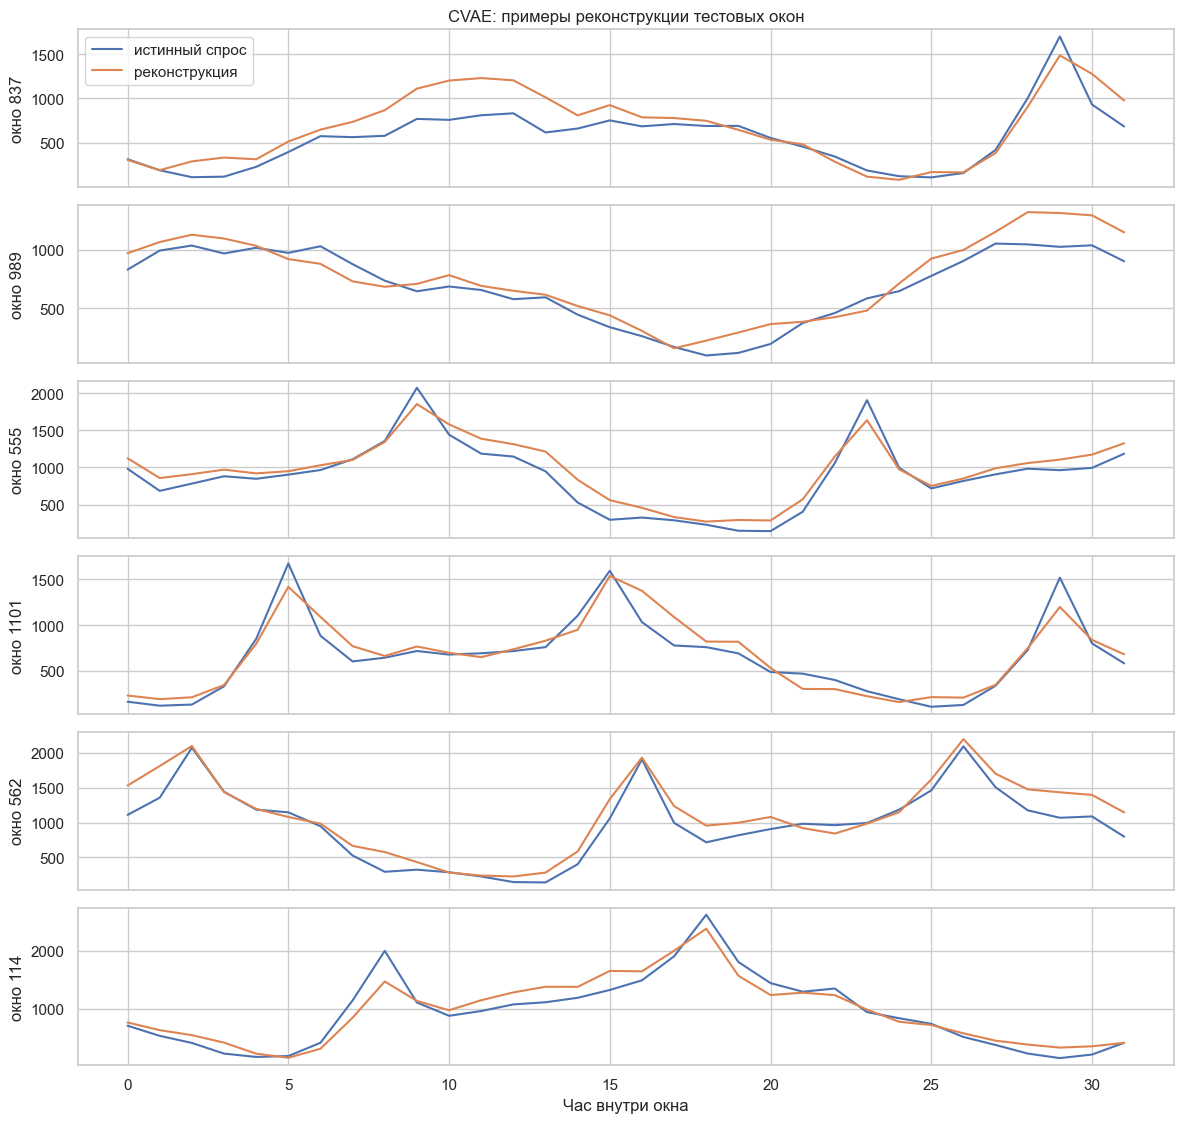

In [154]:
def plot_window_reconstructions(
    true_windows: np.ndarray,
    recon_windows: np.ndarray,
    title: str,
    n_examples: int = 6,
) -> None:
    """Показывает выбранные истинные и восстановленные окна спроса для визуальной проверки реконструкции"""
    rng = np.random.default_rng(CONFIG["plots"]["seed"])
    indices = rng.choice(len(true_windows), size=min(n_examples, len(true_windows)), replace=False)

    fig, axes = plt.subplots(len(indices), 1, figsize=(12, 1.9 * len(indices)), sharex=True)
    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        ax.plot(true_windows[idx], label="истинный спрос", linewidth=1.5)
        ax.plot(recon_windows[idx], label="реконструкция", linewidth=1.5)
        ax.set_ylabel(f"окно {idx}")

    axes[0].set_title(title)
    axes[-1].set_xlabel("Час внутри окна")
    axes[0].legend()
    plt.tight_layout()
    plt.show()


plot_window_reconstructions(
    cvae_eval["true"],
    cvae_eval["recon"],
    "CVAE: примеры реконструкции тестовых окон",
)

Оконные реконструкции CVAE показывают локальное качество восстановления формы спроса: важно смотреть, удерживает ли модель пики, ночные провалы и резкие изменения внутри 32-часового фрагмента

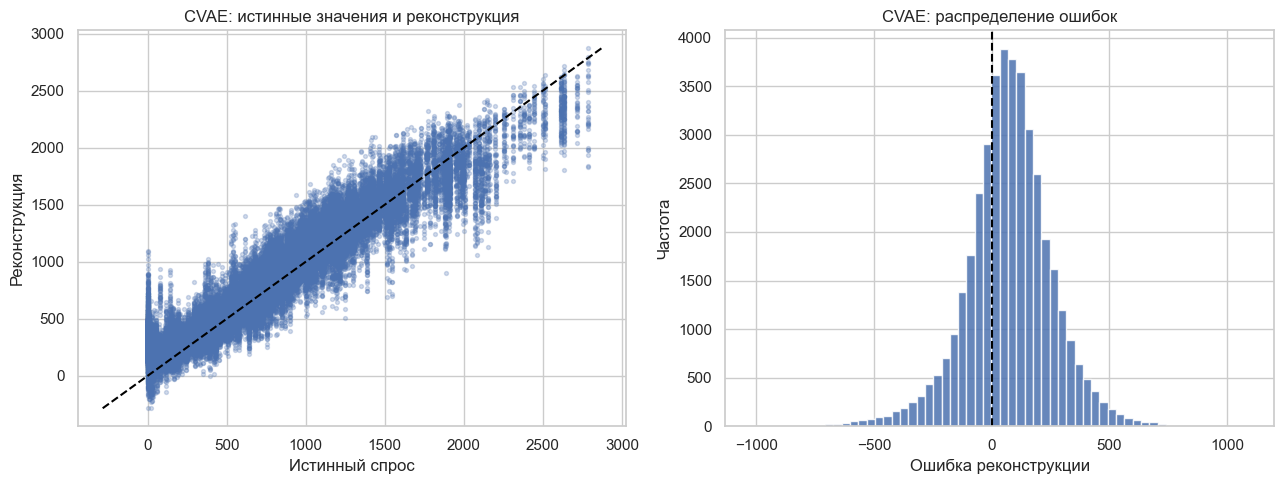

In [155]:
def plot_scatter_and_errors(
    true_values: np.ndarray,
    recon_values: np.ndarray,
    title_prefix: str,
) -> None:
    """Строит scatter истинных и восстановленных значений и гистограмму ошибок реконструкции"""
    y_true = true_values.ravel()
    y_pred = recon_values.ravel()
    errors = y_pred - y_true

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].scatter(y_true, y_pred, s=8, alpha=0.25)
    min_value = min(y_true.min(), y_pred.min())
    max_value = max(y_true.max(), y_pred.max())
    axes[0].plot([min_value, max_value], [min_value, max_value], color="black", linestyle="--")
    axes[0].set_title(f"{title_prefix}: истинные значения и реконструкция")
    axes[0].set_xlabel("Истинный спрос")
    axes[0].set_ylabel("Реконструкция")

    axes[1].hist(errors, bins=60, alpha=0.85)
    axes[1].axvline(0, color="black", linestyle="--")
    axes[1].set_title(f"{title_prefix}: распределение ошибок")
    axes[1].set_xlabel("Ошибка реконструкции")
    axes[1].set_ylabel("Частота")
    plt.tight_layout()
    plt.show()


plot_scatter_and_errors(cvae_eval["true"], cvae_eval["recon"], "CVAE")

Метрики CVAE в исходной шкале показывают, насколько хорошо модель восстанавливает количество аренд в час. Scatter-график дополняет таблицу: чем плотнее точки лежат около диагонали, тем меньше систематическое смещение реконструкции

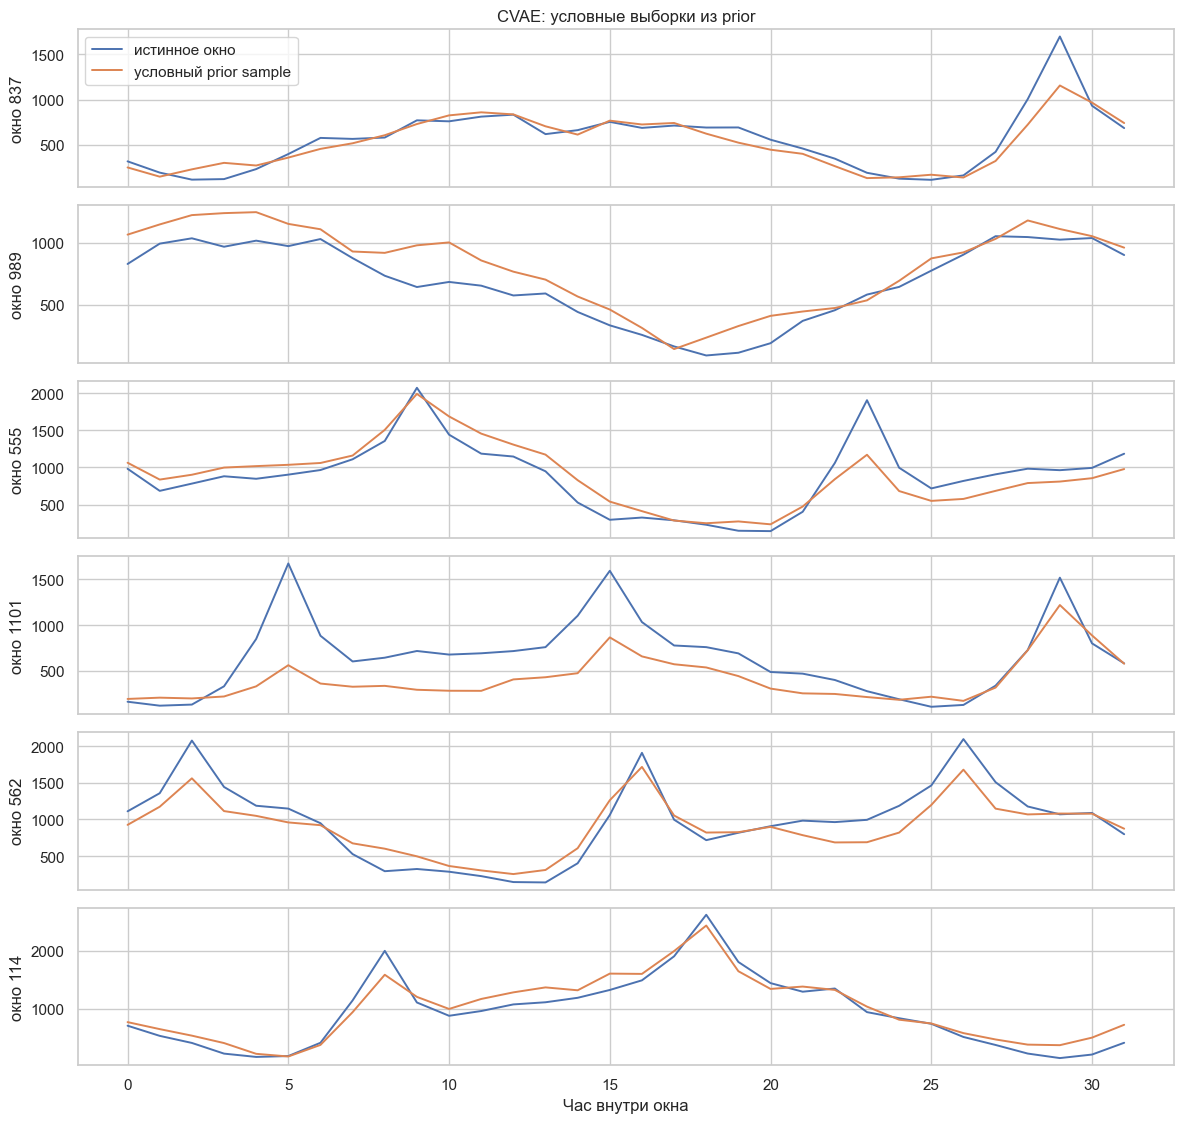

In [156]:
def plot_cvae_prior_samples(
    model: ConditionalVAE,
    source_windows: np.ndarray,
    n_examples: int = 6,
) -> None:
    """Показывает условные выборки CVAE из prior рядом с реальными окнами того же контекста"""
    rng = np.random.default_rng(CONFIG["plots"]["seed"])
    indices = rng.choice(len(source_windows), size=min(n_examples, len(source_windows)), replace=False)
    # copy нужен, потому что окна могли быть созданы как stride view
    x = torch.from_numpy(np.array(source_windows[indices], dtype=np.float32, copy=True)).to(device)

    model.eval()
    with torch.no_grad():
        # генерируем только target; condition берется из реальных окон
        _, condition = model.split_window(x)
        samples_scaled = model.sample_prior(condition).detach().cpu().numpy()
        true_scaled = x[..., TARGET_IDX].detach().cpu().numpy()

    samples = inverse_scale_target(samples_scaled)
    true = inverse_scale_target(true_scaled)

    fig, axes = plt.subplots(len(indices), 1, figsize=(12, 1.9 * len(indices)), sharex=True)
    if len(indices) == 1:
        axes = [axes]

    for ax, idx, true_window, sample_window in zip(axes, indices, true, samples):
        ax.plot(true_window, label="истинное окно", linewidth=1.4)
        ax.plot(sample_window, label="условный prior sample", linewidth=1.4)
        ax.set_ylabel(f"окно {idx}")

    axes[0].set_title("CVAE: условные выборки из prior")
    axes[-1].set_xlabel("Час внутри окна")
    axes[0].legend()
    plt.tight_layout()
    plt.show()


plot_cvae_prior_samples(cvae, test_windows)

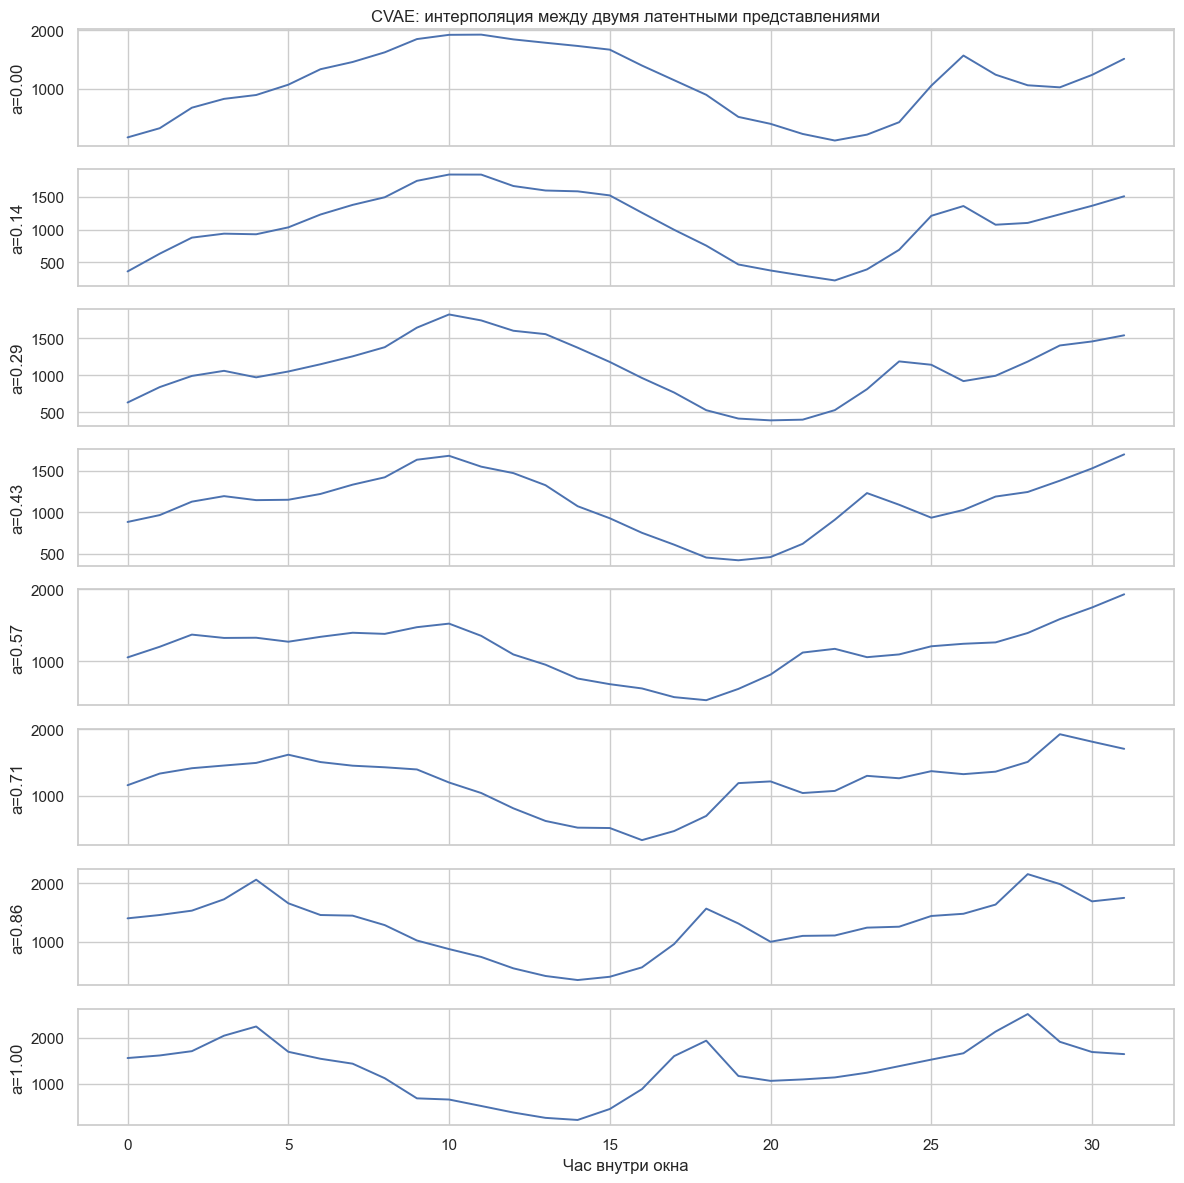

In [157]:
def plot_cvae_interpolation(
    model: ConditionalVAE,
    source_windows: np.ndarray,
    idx_a: int = 0,
    idx_b: int = 200,
    steps: int = 8,
) -> None:
    """Визуализирует плавную интерполяцию между двумя окнами в латентном пространстве CVAE"""
    idx_b = min(idx_b, len(source_windows) - 1)
    x = torch.from_numpy(np.array(source_windows[[idx_a, idx_b]], dtype=np.float32, copy=True)).to(device)

    model.eval()
    with torch.no_grad():
        target, condition = model.split_window(x)
        # интерполируем в пространстве средних латентного posterior
        mu, _ = model.encode_from_parts(target, condition)

        reconstructions = []
        for alpha in np.linspace(0, 1, steps):
            # условие тоже интерполируется, чтобы вход декодера был согласованным
            z = (1 - alpha) * mu[0:1] + alpha * mu[1:2]
            cond = (1 - alpha) * condition[0:1] + alpha * condition[1:2]
            reconstructions.append(model.decode(z, cond).detach().cpu().numpy()[0])

    reconstructions = inverse_scale_target(np.stack(reconstructions))

    fig, axes = plt.subplots(steps, 1, figsize=(12, 1.5 * steps), sharex=True)
    for ax, alpha, window in zip(axes, np.linspace(0, 1, steps), reconstructions):
        ax.plot(window, linewidth=1.4)
        ax.set_ylabel(f"a={alpha:.2f}")

    axes[0].set_title("CVAE: интерполяция между двумя латентными представлениями")
    axes[-1].set_xlabel("Час внутри окна")
    plt.tight_layout()
    plt.show()


plot_cvae_interpolation(cvae, test_windows)

Условные выборки из prior проверяют генеративную часть CVAE: декодер получает реальный контекст, но не получает истинный целевой ряд. Интерполяция показывает, меняется ли реконструкция плавно при движении в латентном пространстве, что важно для интерпретируемости непрерывного `z`

## Эксперимент с разными значениями beta

Параметр `beta` задает силу KL-регуляризации:

$$
\mathcal{L} = \mathcal{L}_{rec} + \beta \cdot KL(q_\phi(z \mid x, y) \Vert p(z)).
$$

Малые значения `beta` обычно дают более точную реконструкцию, но менее регулярное латентное пространство. Большие значения усиливают близость к prior, но могут ухудшать восстановление спроса и приводить к недоиспользованию `z`.

In [158]:
def get_cvae_val_stats(
    model: ConditionalVAE,
    val_loader: DataLoader,
    device: torch.device,
) -> Dict[str, float]:
    """Считает validation метрики CVAE в исходной шкале и средний KL на окно"""
    outputs = collect_cvae_outputs(model, val_loader, device)
    eval_result = evaluate_scaled_windows(outputs["target"], outputs["recon"])
    mu = outputs["mu"]
    logvar = outputs["logvar"]
    # тот же KL считаем по каждому окну для сравнения beta
    kl_per_window = 0.5 * np.sum(mu ** 2 + np.exp(logvar) - 1 - logvar, axis=1)
    return {
        "val_MSE_original_scale": eval_result["metrics"]["MSE"],
        "val_MAE_original_scale": eval_result["metrics"]["MAE"],
        "mean_KL_per_window": float(kl_per_window.mean()),
    }


def run_beta_experiment(
    beta_values: List[float],
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
) -> pd.DataFrame:
    """Запускает серию обучений CVAE с разными beta и собирает итоговые validation-статистики"""
    rows = []

    for beta in beta_values:
        print(f"\n=== beta = {beta} ===")
        # одинаковый seed делает запуски beta более сопоставимыми
        set_seed(CONFIG["seed"])
        model = ConditionalVAE(
            window_size=WINDOW_SIZE,
            num_features=len(FEATURES),
            target_idx=TARGET_IDX,
            latent_dim=CONFIG["cvae"]["latent_dim"],
            hidden_dims=CONFIG["cvae"]["hidden_dims"],
        ).to(device)

        # warmup_epochs=1 превращает beta в фиксированное значение
        experiment_config = {
            **CONFIG["cvae"],
            "epochs": CONFIG["beta_experiment"]["epochs"],
            "beta_max": beta,
            "warmup_epochs": 1,
        }
        history = train_conditional_vae(model, train_loader, val_loader, experiment_config, device)
        val_stats = get_cvae_val_stats(model, val_loader, device)

        rows.append({
            "beta": beta,
            "final_train_recon": history["train_recon"][-1],
            "final_train_kl": history["train_kl"][-1],
            "final_val_recon": history["val_recon"][-1],
            "final_val_kl": history["val_kl"][-1],
            **val_stats,
        })

    return pd.DataFrame(rows)

In [159]:
beta_df = run_beta_experiment(
    CONFIG["beta_experiment"]["values"],
    train_loader,
    val_loader,
    device,
)

display(beta_df)


=== beta = 0.001 ===
Epoch 001 | beta=0.0010 | train=23.9532 | val=26.8602 | train_recon=23.9474 | train_kl=5.8661
Epoch 010 | beta=0.0010 | train=3.1729 | val=8.8451 | train_recon=3.1286 | train_kl=44.2698
Epoch 020 | beta=0.0010 | train=1.9132 | val=6.6871 | train_recon=1.8748 | train_kl=38.3823
Epoch 030 | beta=0.0010 | train=1.4227 | val=6.0389 | train_recon=1.3877 | train_kl=34.9952
Epoch 040 | beta=0.0010 | train=1.1587 | val=5.7116 | train_recon=1.1255 | train_kl=33.2005
Epoch 050 | beta=0.0010 | train=1.0042 | val=5.4554 | train_recon=0.9724 | train_kl=31.8677
Epoch 060 | beta=0.0010 | train=0.8947 | val=5.2237 | train_recon=0.8641 | train_kl=30.5747
Epoch 070 | beta=0.0010 | train=0.8105 | val=5.1305 | train_recon=0.7805 | train_kl=29.9598
Epoch 080 | beta=0.0010 | train=0.7372 | val=5.0267 | train_recon=0.7082 | train_kl=28.9987
Epoch 090 | beta=0.0010 | train=0.6820 | val=4.9817 | train_recon=0.6536 | train_kl=28.3614
Epoch 100 | beta=0.0010 | train=0.6416 | val=4.9981 | tr

,beta,final_train_recon,final_train_kl,final_val_recon,final_val_kl,val_MSE_original_scale,val_MAE_original_scale,mean_KL_per_window
0,0.001,0.383224,26.029035,4.490624,29.578669,56740.644531,175.177643,29.578671
1,0.010,0.440446,8.377875,4.992814,10.324873,63085.984375,182.549576,10.324872
2,0.050,0.568441,3.230596,6.127238,5.193932,77419.843750,199.249405,5.193932
3,0.100,0.665408,1.583014,7.471017,3.302241,94398.968750,219.854645,3.302241
4,0.500,0.761855,0.000028,10.765777,0.001088,136029.437500,265.087524,0.001088
5,1.000,0.771707,0.000008,11.086158,0.001362,140077.562500,270.614746,0.001362


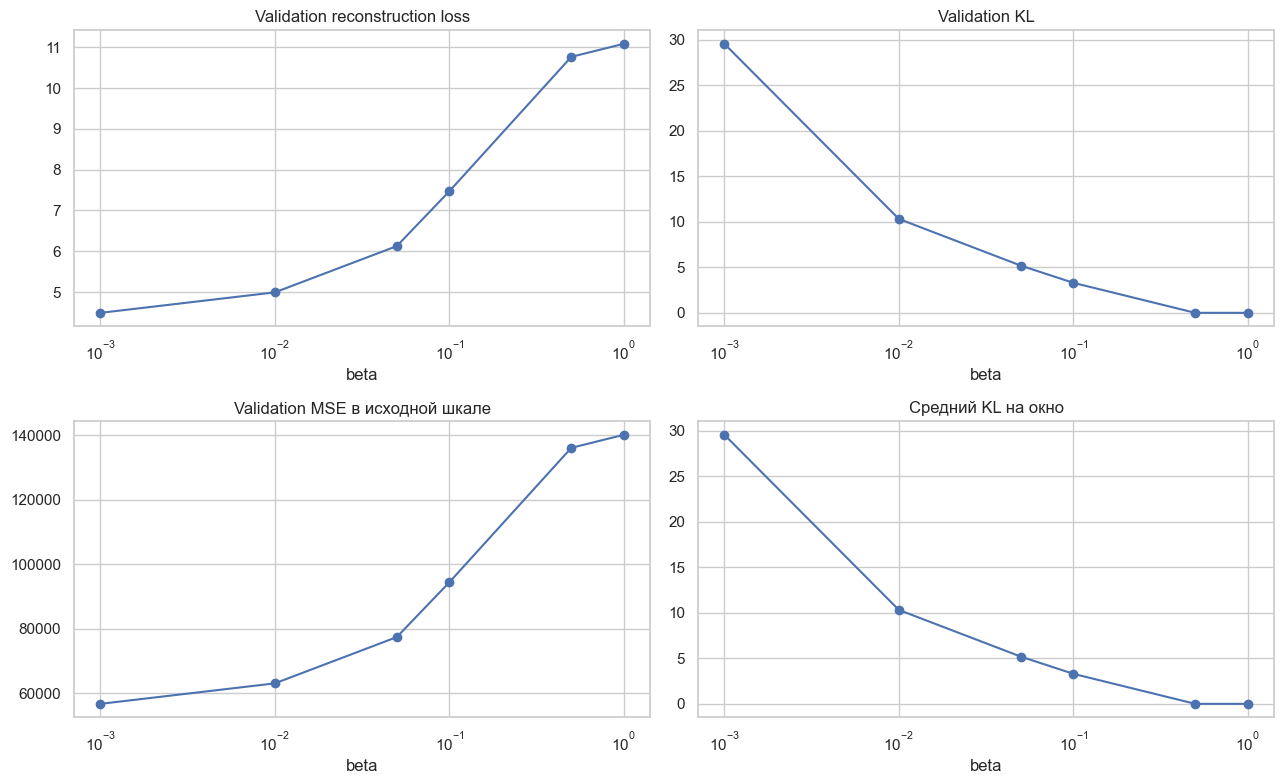

In [160]:
def plot_beta_experiment_results(beta_df: pd.DataFrame) -> None:
    """Строит графики beta-эксперимента для анализа компромисса reconstruction и KL"""
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))

    axes[0, 0].plot(beta_df["beta"], beta_df["final_val_recon"], marker="o")
    axes[0, 0].set_title("Validation reconstruction loss")

    axes[0, 1].plot(beta_df["beta"], beta_df["final_val_kl"], marker="o")
    axes[0, 1].set_title("Validation KL")

    axes[1, 0].plot(beta_df["beta"], beta_df["val_MSE_original_scale"], marker="o")
    axes[1, 0].set_title("Validation MSE в исходной шкале")

    axes[1, 1].plot(beta_df["beta"], beta_df["mean_KL_per_window"], marker="o")
    axes[1, 1].set_title("Средний KL на окно")

    for ax in axes.ravel():
        ax.set_xscale("log")
        ax.set_xlabel("beta")
    plt.tight_layout()
    plt.show()


plot_beta_experiment_results(beta_df)

В beta-эксперименте основная цель — увидеть компромисс между точностью восстановления и силой KL-регуляризации. Лучшее значение beta выбирается по validation-метрикам, но сами графики важны не меньше таблицы: если при росте beta MSE увеличивается, это естественная цена более жесткого приближения posterior к prior

## Conditional VQ-VAE

`Conditional VQ-VAE` заменяет непрерывный латентный вектор дискретными кодами. Энкодер сначала строит несколько латентных токенов, затем каждый токен заменяется ближайшим вектором из обучаемой кодовой книги.

Кодовая книга играет роль набора прототипов. Если модель использует много кодов и их распределения похожи на train, validation и test, дискретное латентное пространство можно интерпретировать как набор повторяющихся типов окон спроса.

In [161]:
class VectorQuantizer(nn.Module):
    def __init__(self, num_embeddings: int, embedding_dim: int, commitment_beta: float) -> None:
        """Инициализирует векторный квантователь с обучаемой кодовой книгой фиксированного размера"""
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.commitment_beta = commitment_beta
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.uniform_(-1 / num_embeddings, 1 / num_embeddings)

    def forward(self, z_e: torch.Tensor) -> Dict[str, torch.Tensor]:
        """Квантует encoder output в ближайшие коды и возвращает quantized vectors, losses, indices и perplexity"""
        flat_z = z_e.reshape(-1, self.embedding_dim)

        # расстояния считаются от каждого токена до всех кодов
        distances = (
            flat_z.pow(2).sum(dim=1, keepdim=True)
            + self.embedding.weight.pow(2).sum(dim=1)
            - 2 * flat_z @ self.embedding.weight.t()
        )
        # каждый токен заменяется ближайшим вектором кодовой книги
        indices = torch.argmin(distances, dim=1)
        z_q = self.embedding(indices).view_as(z_e)

        # codebook loss двигает коды, commitment удерживает энкодер у выбранных кодов
        codebook_loss = F.mse_loss(z_q, z_e.detach())
        commitment_loss = F.mse_loss(z_e, z_q.detach())
        vq_loss = codebook_loss + self.commitment_beta * commitment_loss

        # straight-through estimator: вперед идет квантованный вектор, назад — градиент энкодера
        z_q_st = z_e + (z_q - z_e).detach()

        # perplexity показывает эффективное число используемых кодов
        encodings = F.one_hot(indices, self.num_embeddings).float()
        avg_probs = encodings.mean(dim=0)
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))

        return {
            "z_q": z_q_st,
            "indices": indices.view(z_e.shape[0], z_e.shape[1]),
            "vq_loss": vq_loss,
            "codebook_loss": codebook_loss,
            "commitment_loss": commitment_loss,
            "perplexity": perplexity,
        }

In [162]:
class ConditionalVQVAE(nn.Module):
    def __init__(
        self,
        window_size: int,
        num_features: int,
        target_idx: int,
        num_embeddings: int,
        embedding_dim: int,
        num_latent_tokens: int,
        commitment_beta: float,
        hidden_dims: Tuple[int, ...],
    ) -> None:
        """Инициализирует ConditionalVQVAE с encoder, vector quantizer и decoder для условной реконструкции окон"""
        super().__init__()
        self.window_size = window_size
        self.num_features = num_features
        self.target_idx = target_idx
        self.cond_idx = [i for i in range(num_features) if i != target_idx]
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.num_latent_tokens = num_latent_tokens

        self.target_dim = window_size
        self.cond_dim = window_size * (num_features - 1)
        encoder_input_dim = self.target_dim + self.cond_dim
        # несколько latent tokens квантуются независимо
        latent_dim = num_latent_tokens * embedding_dim

        encoder_layers: List[nn.Module] = []
        prev_dim = encoder_input_dim
        for hidden_dim in hidden_dims:
            encoder_layers.extend([nn.Linear(prev_dim, hidden_dim), nn.ReLU()])
            prev_dim = hidden_dim
        encoder_layers.append(nn.Linear(prev_dim, latent_dim))
        self.encoder = nn.Sequential(*encoder_layers)

        # квантователь связывает непрерывный encoder output с дискретной кодовой книгой
        self.quantizer = VectorQuantizer(num_embeddings, embedding_dim, commitment_beta)

        decoder_layers: List[nn.Module] = []
        prev_dim = latent_dim + self.cond_dim
        for hidden_dim in reversed(hidden_dims):
            decoder_layers.extend([nn.Linear(prev_dim, hidden_dim), nn.ReLU()])
            prev_dim = hidden_dim
        decoder_layers.append(nn.Linear(prev_dim, self.target_dim))
        self.decoder = nn.Sequential(*decoder_layers)

    def split_window(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """Разделяет полное окно на целевой ряд и condition так же, как в ConditionalVAE"""
        # отделяем целевой ряд от условий так же, как в CVAE
        target = x[..., self.target_idx]
        condition = x[..., self.cond_idx].reshape(x.size(0), -1)
        return target, condition

    def encode(self, target: torch.Tensor, condition: torch.Tensor) -> torch.Tensor:
        """Кодирует target и condition в набор непрерывных latent tokens перед квантованием"""
        z_e = self.encoder(torch.cat([target, condition], dim=1))
        # MLP-выход разворачивается в последовательность latent tokens
        return z_e.view(target.size(0), self.num_latent_tokens, self.embedding_dim)

    def decode(self, z_q: torch.Tensor, condition: torch.Tensor) -> torch.Tensor:
        """Восстанавливает целевое окно из квантованных latent tokens и condition"""
        z_flat = z_q.reshape(z_q.size(0), -1)
        return self.decoder(torch.cat([z_flat, condition], dim=1))

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        """Выполняет полный проход ConditionalVQVAE от окна к реконструкции и индексам кодовой книги"""
        target, condition = self.split_window(x)
        z_e = self.encode(target, condition)
        # декодер получает уже квантованные токены
        quantized = self.quantizer(z_e)
        recon = self.decode(quantized["z_q"], condition)
        return {
            "recon": recon,
            "target": target,
            **quantized,
        }

    def encode_to_indices(self, x: torch.Tensor) -> torch.Tensor:
        """Возвращает только индексы кодовой книги для анализа дискретного латентного пространства"""
        target, condition = self.split_window(x)
        z_e = self.encode(target, condition)
        # индексы нужны для анализа использования кодовой книги
        return self.quantizer(z_e)["indices"]

In [163]:
def run_cvqvae_epoch(
    model: ConditionalVQVAE,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer | None,
    device: torch.device,
) -> Dict[str, float]:
    """Выполняет одну эпоху обучения или валидации ConditionalVQVAE и усредняет reconstruction, codebook, commitment и perplexity"""
    is_train = optimizer is not None
    model.train(is_train)
    totals = {
        "total": 0.0,
        "recon": 0.0,
        "codebook": 0.0,
        "commitment": 0.0,
        "perplexity": 0.0,
    }
    n_samples = 0

    for (x_batch,) in loader:
        x_batch = x_batch.to(device)
        if is_train:
            optimizer.zero_grad()

        outputs = model(x_batch)
        recon_loss = F.mse_loss(outputs["recon"], outputs["target"], reduction="mean")
        # vq_loss уже включает codebook и commitment компоненты
        total_loss = recon_loss + outputs["vq_loss"]

        if is_train:
            total_loss.backward()
            optimizer.step()

        batch_size = x_batch.size(0)
        n_samples += batch_size
        totals["total"] += float(total_loss.detach().cpu()) * batch_size
        totals["recon"] += float(recon_loss.detach().cpu()) * batch_size
        totals["codebook"] += float(outputs["codebook_loss"].detach().cpu()) * batch_size
        totals["commitment"] += float(outputs["commitment_loss"].detach().cpu()) * batch_size
        totals["perplexity"] += float(outputs["perplexity"].detach().cpu()) * batch_size

    return {key: value / n_samples for key, value in totals.items()}

In [164]:
def train_conditional_vqvae(
    model: ConditionalVQVAE,
    train_loader: DataLoader,
    val_loader: DataLoader,
    config: Dict,
    device: torch.device,
) -> Dict[str, List[float]]:
    """Обучает ConditionalVQVAE и сохраняет историю потерь и perplexity для train и validation"""
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
    # отдельно сохраняем reconstruction, codebook, commitment и perplexity
    history = {
        "train_total": [],
        "train_recon": [],
        "train_codebook": [],
        "train_commitment": [],
        "train_perplexity": [],
        "val_total": [],
        "val_recon": [],
        "val_codebook": [],
        "val_commitment": [],
        "val_perplexity": [],
    }

    for epoch in range(1, config["epochs"] + 1):
        train_stats = run_cvqvae_epoch(model, train_loader, optimizer, device)
        val_stats = run_cvqvae_epoch(model, val_loader, None, device)

        for key in ["total", "recon", "codebook", "commitment", "perplexity"]:
            history[f"train_{key}"].append(train_stats[key])
            history[f"val_{key}"].append(val_stats[key])

        if epoch == 1 or epoch % 10 == 0 or epoch == config["epochs"]:
            print(
                f"Epoch {epoch:03d} | train={train_stats['total']:.4f} | "
                f"val={val_stats['total']:.4f} | recon={train_stats['recon']:.4f} | "
                f"perplexity={train_stats['perplexity']:.2f}"
            )

    return history

In [165]:
def plot_conditional_vq_history(history: Dict[str, List[float]]) -> None:
    """Визуализирует динамику total, reconstruction, codebook, commitment loss и perplexity для VQ-VAE"""
    fig, axes = plt.subplots(3, 2, figsize=(13, 11))
    plot_items = [
        ("total", "Total loss"),
        ("recon", "Reconstruction loss"),
        ("codebook", "Codebook loss"),
        ("commitment", "Commitment loss"),
        ("perplexity", "Perplexity"),
    ]

    for ax, (key, title) in zip(axes.ravel(), plot_items):
        ax.plot(history[f"train_{key}"], label="train")
        ax.plot(history[f"val_{key}"], label="validation")
        ax.set_title(f"VQ-VAE: {title}")
        ax.set_xlabel("Epoch")
        ax.legend()

    axes.ravel()[-1].axis("off")
    plt.tight_layout()
    plt.show()

In [166]:
cvqvae = ConditionalVQVAE(
    window_size=WINDOW_SIZE,
    num_features=len(FEATURES),
    target_idx=TARGET_IDX,
    num_embeddings=CONFIG["vqvae"]["num_embeddings"],
    embedding_dim=CONFIG["vqvae"]["embedding_dim"],
    num_latent_tokens=CONFIG["vqvae"]["num_latent_tokens"],
    commitment_beta=CONFIG["vqvae"]["commitment_beta"],
    hidden_dims=CONFIG["vqvae"]["hidden_dims"],
).to(device)

print(cvqvae)
print("VQ-VAE encoder input dim:", cvqvae.target_dim + cvqvae.cond_dim)
print("VQ-VAE decoder input dim:", cvqvae.num_latent_tokens * cvqvae.embedding_dim + cvqvae.cond_dim)

cvq_history = train_conditional_vqvae(
    cvqvae,
    train_loader,
    val_loader,
    CONFIG["vqvae"],
    device,
)

ConditionalVQVAE(
  (encoder): Sequential(
    (0): Linear(in_features=544, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=32, bias=True)
  )
  (quantizer): VectorQuantizer(
    (embedding): Embedding(32, 8)
  )
  (decoder): Sequential(
    (0): Linear(in_features=544, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=32, bias=True)
  )
)
VQ-VAE encoder input dim: 544
VQ-VAE decoder input dim: 544
Epoch 001 | train=0.5216 | val=0.9630 | recon=0.4913 | perplexity=12.00
Epoch 010 | train=0.0832 | val=0.4398 | recon=0.0740 | perplexity=26.97
Epoch 020 | train=0.0502 | val=0.3525 | recon=0.0460 | perplex

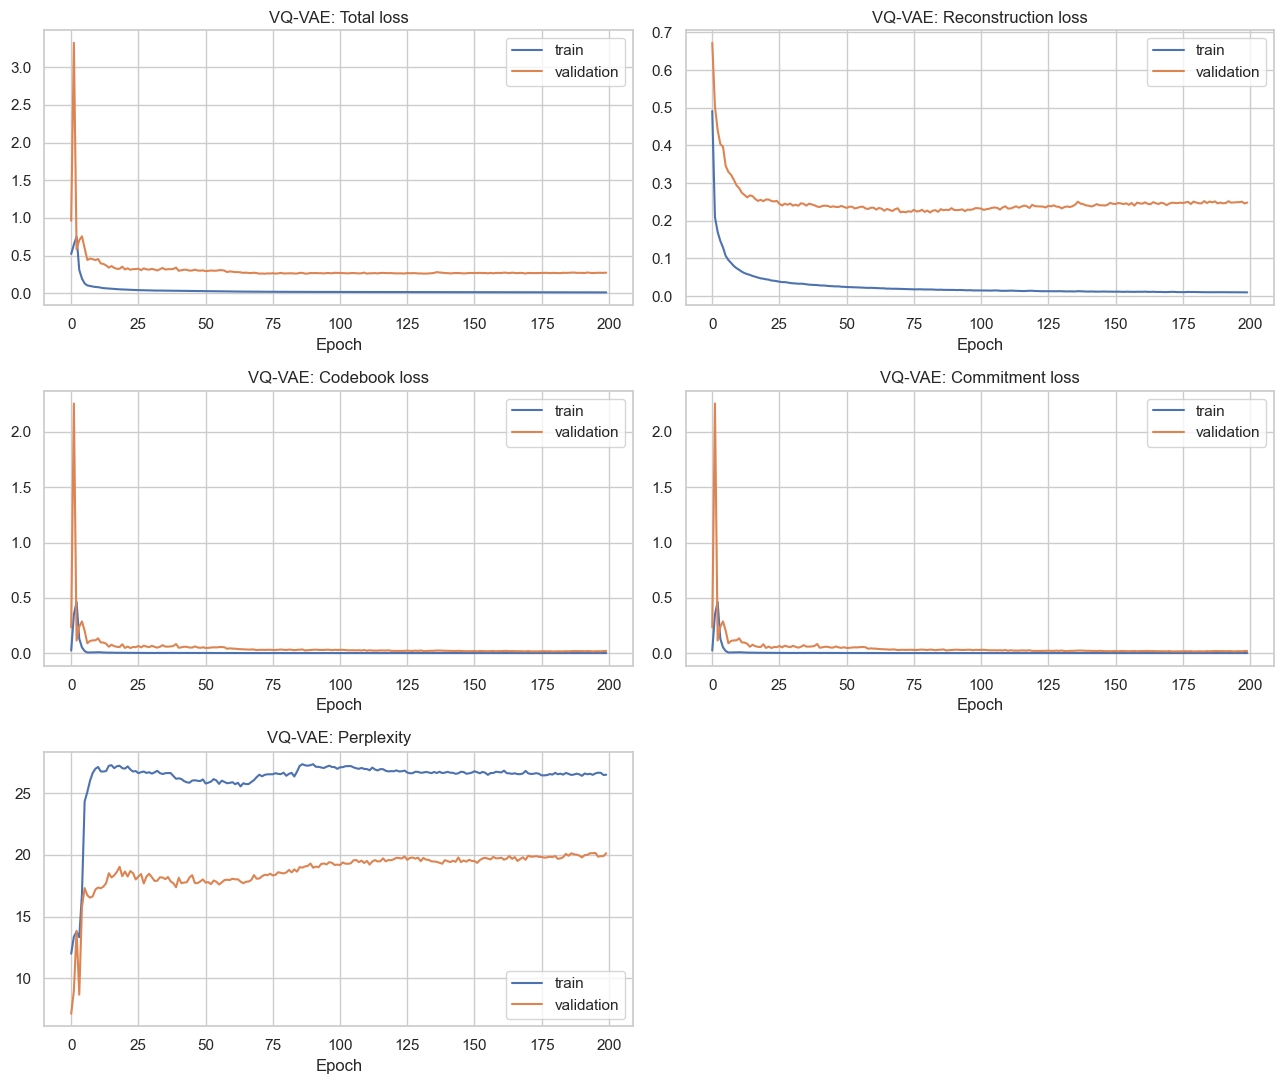

In [167]:
plot_conditional_vq_history(cvq_history)

Для VQ-VAE важны две группы кривых: reconstruction loss показывает качество восстановления, а perplexity показывает, насколько активно используется кодовая книга. Низкая perplexity может указывать на слабое разнообразие дискретных кодов

## Оценка Conditional VQ-VAE

VQ-VAE оценивается теми же метриками и на той же тестовой выборке, что и CVAE. Это важно: сравниваются не внутренние loss-функции, а качество реконструкции спроса в исходной шкале.

In [168]:
def collect_conditional_vq_outputs(
    model: ConditionalVQVAE,
    loader: DataLoader,
    device: torch.device,
) -> Dict[str, np.ndarray]:
    """Собирает реконструкции, целевые окна и индексы кодов VQ-VAE по всему DataLoader"""
    model.eval()
    # вместе с реконструкцией сохраняем дискретные коды
    collected = {"recon": [], "target": [], "indices": []}

    with torch.no_grad():
        for (x_batch,) in loader:
            x_batch = x_batch.to(device)
            outputs = model(x_batch)
            collected["recon"].append(outputs["recon"].detach().cpu().numpy())
            collected["target"].append(outputs["target"].detach().cpu().numpy())
            collected["indices"].append(outputs["indices"].detach().cpu().numpy())

    return {key: np.concatenate(value, axis=0) for key, value in collected.items()}


def evaluate_conditional_vqvae(
    model: ConditionalVQVAE,
    loader: DataLoader,
    device: torch.device,
) -> Dict[str, object]:
    """Оценивает ConditionalVQVAE в исходной шкале и сохраняет индексы кодовой книги"""
    outputs = collect_conditional_vq_outputs(model, loader, device)
    evaluation = evaluate_scaled_windows(outputs["target"], outputs["recon"])
    evaluation["indices"] = outputs["indices"]
    return evaluation

In [169]:
cvq_eval = evaluate_conditional_vqvae(cvqvae, test_loader, device)
cvq_metrics = cvq_eval["metrics"]

comparison_df = pd.DataFrame([
    {"Model": "Conditional VAE", **cvae_metrics},
    {"Model": "Conditional VQ-VAE", **cvq_metrics},
])
display(comparison_df)

,Model,MSE,MAE,R2
0,Conditional VAE,39753.707031,152.157562,0.877184
1,Conditional VQ-VAE,61753.460938,183.433609,0.809217


Таблица сравнивает модели по одинаковым оконным метрикам в исходной шкале. Даже если одна модель лучше по MSE, сравнение нельзя сводить только к ошибке: CVAE дает непрерывное latent-пространство, а VQ-VAE — дискретные коды для анализа режимов спроса

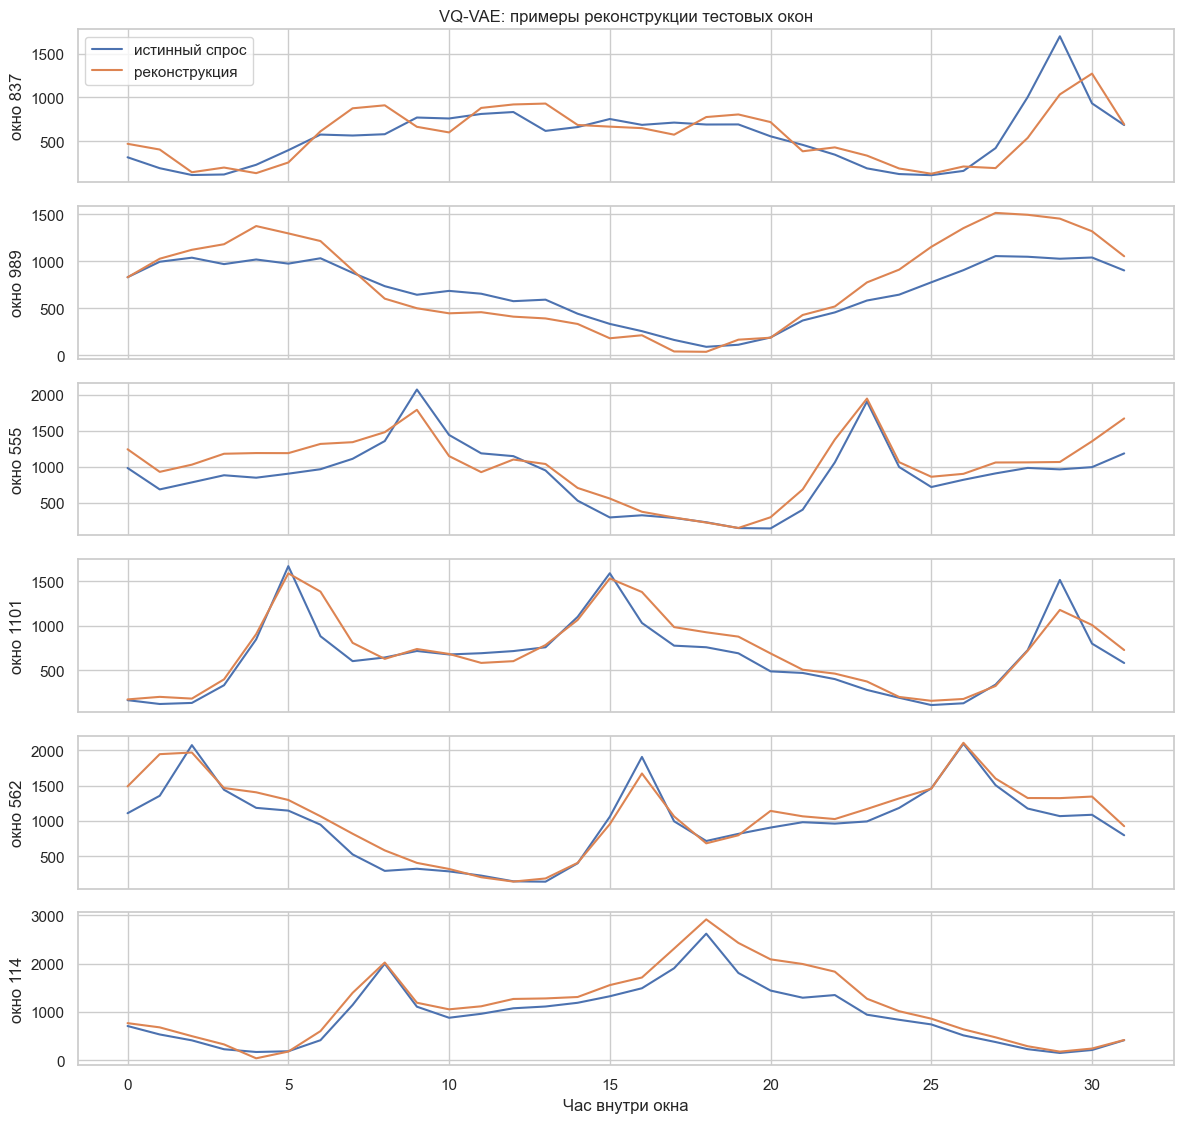

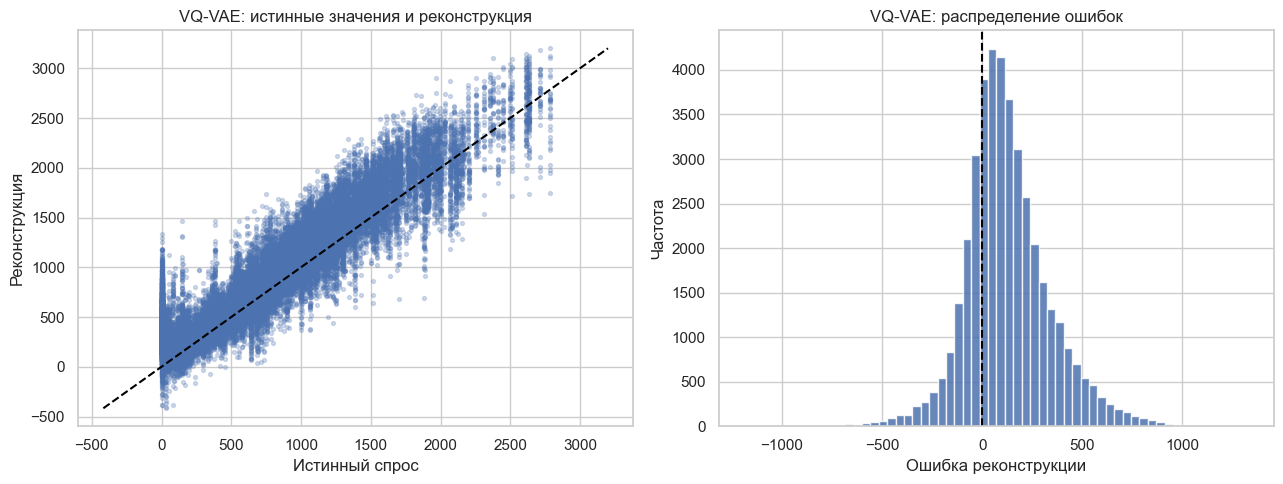

In [170]:
plot_window_reconstructions(
    cvq_eval["true"],
    cvq_eval["recon"],
    "VQ-VAE: примеры реконструкции тестовых окон",
)

plot_scatter_and_errors(cvq_eval["true"], cvq_eval["recon"], "VQ-VAE")

Оценка VQ-VAE должна читаться вместе с анализом кодов. Ошибка реконструкции показывает точность восстановления, а scatter и примеры окон показывают, насколько дискретный bottleneck сохраняет форму спроса. Если разброс заметно шире, чем у CVAE, это может быть ценой кодирования через конечную кодовую книгу

## Анализ кодовой книги

Для VQ-VAE важно не только восстановить окна, но и проверить, использует ли модель дискретное латентное пространство. Если активен только один или несколько кодов, возникает коллапс кодовой книги. Если коды используются разнообразно и похожим образом на train, validation и test, кодовая книга отражает разные типы окон спроса.

In [171]:
def collect_vq_code_indices(
    model: ConditionalVQVAE,
    loader: DataLoader,
    device: torch.device,
) -> np.ndarray:
    """Собирает индексы кодовой книги VQ-VAE для всех окон заданного DataLoader"""
    model.eval()
    indices = []
    with torch.no_grad():
        for (x_batch,) in loader:
            x_batch = x_batch.to(device)
            indices.append(model.encode_to_indices(x_batch).detach().cpu().numpy())
    return np.concatenate(indices, axis=0)


def get_code_usage_df(code_indices: np.ndarray, num_embeddings: int) -> pd.DataFrame:
    """Считает частоты и доли использования каждого кода с учетом неиспользованных кодов"""
    # считаем все token positions вместе, включая неиспользованные коды
    flat = code_indices.reshape(-1)
    counts = np.bincount(flat, minlength=num_embeddings)
    usage = pd.DataFrame({
        "code": np.arange(num_embeddings),
        "count": counts,
        "share": counts / counts.sum(),
    })
    return usage

In [172]:
# собираем коды отдельно по split, чтобы проверить стабильность использования
train_code_indices = collect_vq_code_indices(cvqvae, train_loader, device)
val_code_indices = collect_vq_code_indices(cvqvae, val_loader, device)
test_code_indices = collect_vq_code_indices(cvqvae, test_loader, device)

train_usage_df = get_code_usage_df(train_code_indices, cvqvae.num_embeddings)
val_usage_df = get_code_usage_df(val_code_indices, cvqvae.num_embeddings)
test_usage_df = get_code_usage_df(test_code_indices, cvqvae.num_embeddings)

print("Всего кодов:", cvqvae.num_embeddings)
print("Использовано на train:", int((train_usage_df["count"] > 0).sum()))
print("Использовано на validation:", int((val_usage_df["count"] > 0).sum()))
print("Использовано на test:", int((test_usage_df["count"] > 0).sum()))

display(test_usage_df.sort_values("share", ascending=False).head(10))

Всего кодов: 32
Использовано на train: 32
Использовано на validation: 32
Использовано на test: 31


,code,count,share
7,7,448,0.087295
3,3,433,0.084373
18,18,353,0.068784
12,12,340,0.066251
9,9,307,0.059821
19,19,299,0.058262
26,26,287,0.055924
0,0,262,0.051052
2,2,251,0.048909
11,11,214,0.041699


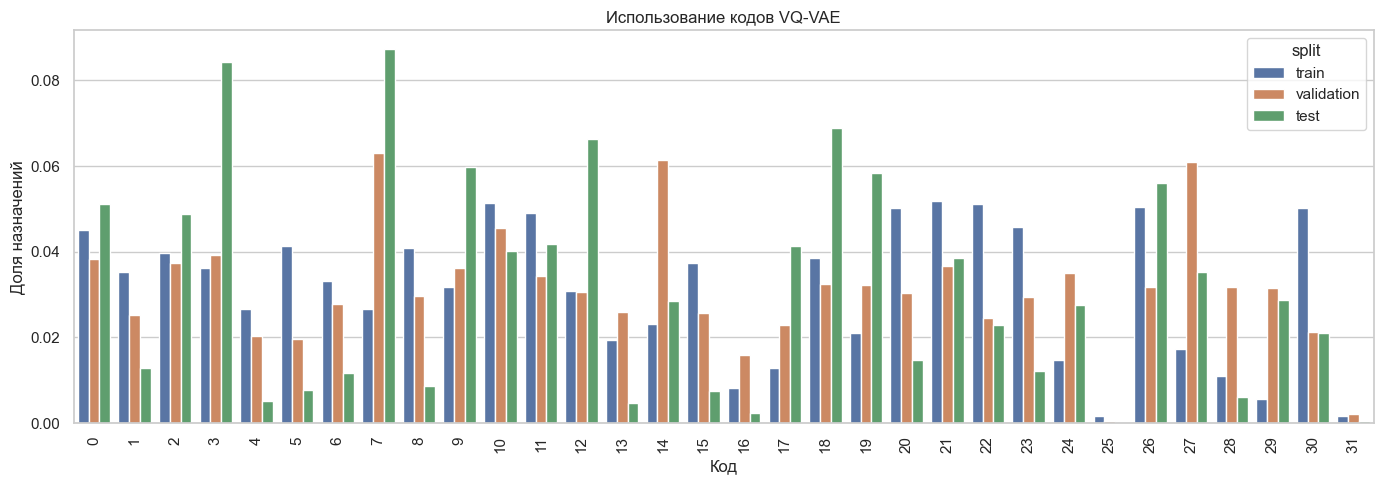

In [173]:
def plot_code_usage_comparison(
    train_usage: pd.DataFrame,
    val_usage: pd.DataFrame,
    test_usage: pd.DataFrame,
) -> None:
    """Сравнивает распределения использования кодов на train, validation и test"""
    # переводим wide-таблицу в long-формат для сравнения split
    usage = pd.DataFrame({
        "code": train_usage["code"],
        "train": train_usage["share"],
        "validation": val_usage["share"],
        "test": test_usage["share"],
    }).melt(id_vars="code", var_name="split", value_name="share")

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.barplot(data=usage, x="code", y="share", hue="split", ax=ax)
    ax.set_title("Использование кодов VQ-VAE")
    ax.set_xlabel("Код")
    ax.set_ylabel("Доля назначений")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


plot_code_usage_comparison(train_usage_df, val_usage_df, test_usage_df)

Таблица и график использования кодов показывают, есть ли коллапс кодовой книги. Хороший признак — когда активны несколько кодов, распределения train, validation и test не расходятся радикально, а самый частый код не забирает почти все назначения

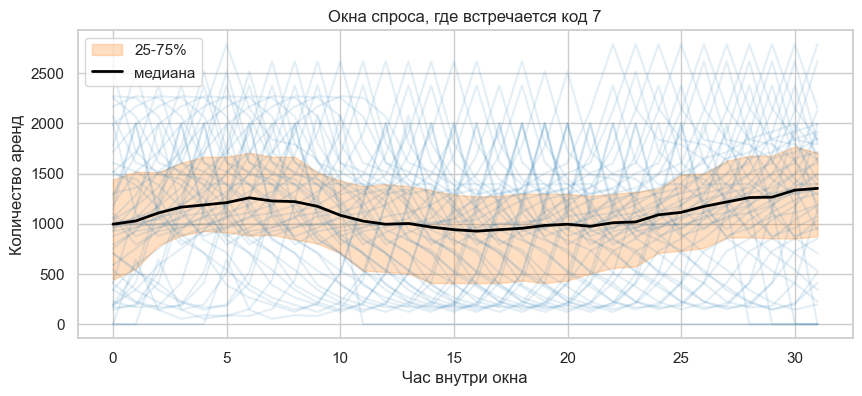

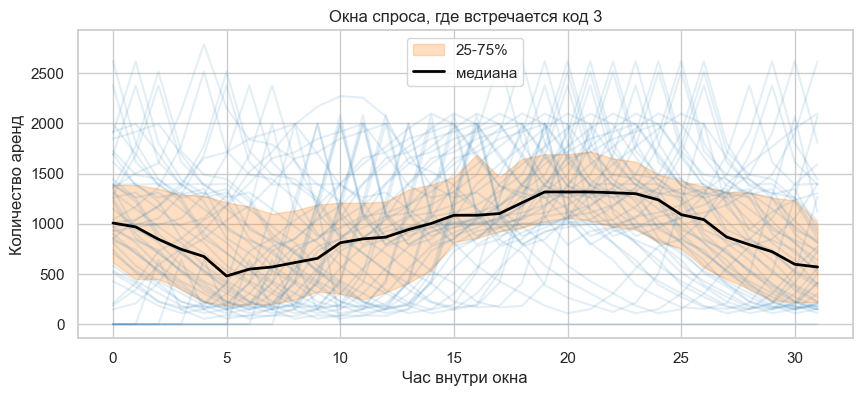

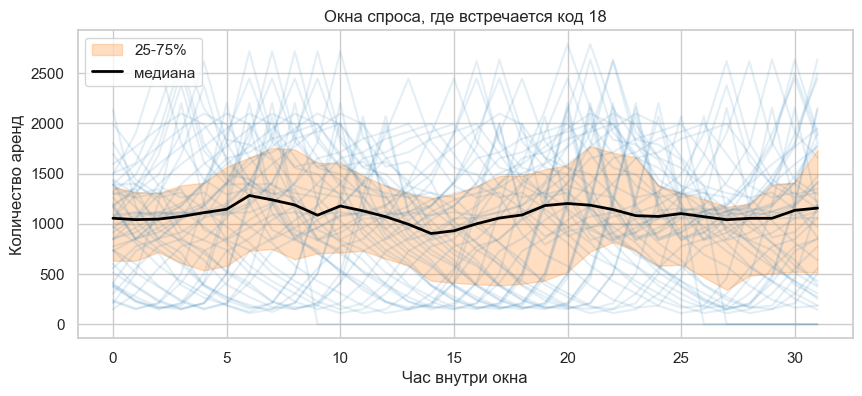

In [174]:
def plot_windows_for_code(
    original_windows: np.ndarray,
    code_indices: np.ndarray,
    code: int,
    max_windows: int = 50,
) -> None:
    """Показывает типичные целевые окна, в которых встречается выбранный код кодовой книги"""
    # окно выбирается, если код встречается хотя бы в одном latent token
    mask = (code_indices == code).any(axis=1)
    selected = original_windows[mask]

    if len(selected) == 0:
        print(f"Для кода {code} нет окон.")
        return

    selected = selected[:max_windows]
    # медиана и квартильный диапазон показывают типичную форму окон
    median = np.median(selected, axis=0)
    q25 = np.percentile(selected, 25, axis=0)
    q75 = np.percentile(selected, 75, axis=0)

    fig, ax = plt.subplots(figsize=(10, 4))
    for window in selected:
        ax.plot(window, color="tab:blue", alpha=0.12)
    ax.fill_between(np.arange(selected.shape[1]), q25, q75, color="tab:orange", alpha=0.25, label="25-75%")
    ax.plot(median, color="black", linewidth=2, label="медиана")
    ax.set_title(f"Окна спроса, где встречается код {code}")
    ax.set_xlabel("Час внутри окна")
    ax.set_ylabel("Количество аренд")
    ax.legend()
    plt.show()


top_codes = test_usage_df.sort_values("share", ascending=False)["code"].head(3).tolist()
for code_id in top_codes:
    plot_windows_for_code(cvq_eval["true"], test_code_indices, int(code_id))

Окна, связанные с частыми кодами, помогают понять, какие формы спроса кодовая книга считает типичными. Медианная линия и межквартильный диапазон показывают общий профиль таких фрагментов

## Склейка перекрывающихся окон

Одна и та же временная точка попадает во многие 32-часовые окна. Поэтому модель может дать несколько разных реконструкций для одного часа: в одном окне эта точка находится в начале, в другом — в середине, в третьем — ближе к концу.

Простая конкатенация окон создала бы скачки на границах. Вместо этого применяется overlap-add: все реконструкции, покрывающие один timestamp, усредняются.

In [175]:
def stitch_windows_mean(
    windows: np.ndarray,
    starts: np.ndarray,
    total_length: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """Склеивает перекрывающиеся реконструированные окна в один ряд через усреднение по покрывающим окнам"""
    result = np.zeros(total_length, dtype=np.float32)
    counts = np.zeros(total_length, dtype=np.float32)  # сколько окон покрывает каждый timestamp

    # усредняем перекрывающиеся реконструкции
    for window, start in zip(windows, starts):
        end = start + len(window)
        result[start:end] += window
        counts[start:end] += 1

    stitched = np.full(total_length, np.nan, dtype=np.float32)
    # на краях меньше перекрытий, поэтому делим только покрытые точки
    mask = counts > 0
    stitched[mask] = result[mask] / counts[mask]
    return stitched, counts

In [176]:
def build_loader_from_windows(windows: np.ndarray, batch_size: int) -> DataLoader:
    """Создает неперемешанный DataLoader из произвольного массива окон"""
    dataset = TensorDataset(windows_to_tensor(windows))
    return DataLoader(dataset, batch_size=batch_size, shuffle=False)


def compute_stitched_reconstructions() -> Dict[str, object]:
    """Строит stitched-реконструкции CVAE и VQ-VAE и считает метрики на покрытых timestamp"""
    cvae_outputs = collect_cvae_outputs(cvae, test_loader, device)
    vq_outputs = collect_conditional_vq_outputs(cvqvae, test_loader, device)

    # склейку и метрики считаем в исходных единицах спроса
    cvae_recon = inverse_scale_target(cvae_outputs["recon"])
    vq_recon = inverse_scale_target(vq_outputs["recon"])
    original = inverse_scale_target(X_test[:, TARGET_IDX])

    cvae_stitched, cvae_counts = stitch_windows_mean(cvae_recon, test_starts, len(X_test))
    vq_stitched, vq_counts = stitch_windows_mean(vq_recon, test_starts, len(X_test))
    # сравниваем только timestamps, где есть реконструкция обеих моделей
    covered = (cvae_counts > 0) & (vq_counts > 0)

    stitched_metrics = pd.DataFrame([
        {
            "Model": "Conditional VAE stitched",
            "MSE": mean_squared_error(original[covered], cvae_stitched[covered]),
            "MAE": mean_absolute_error(original[covered], cvae_stitched[covered]),
            "R2": r2_score(original[covered], cvae_stitched[covered]),
        },
        {
            "Model": "Conditional VQ-VAE stitched",
            "MSE": mean_squared_error(original[covered], vq_stitched[covered]),
            "MAE": mean_absolute_error(original[covered], vq_stitched[covered]),
            "R2": r2_score(original[covered], vq_stitched[covered]),
        },
    ])

    return {
        "original": original,
        "cvae": cvae_stitched,
        "vqvae": vq_stitched,
        "covered": covered,
        "metrics": stitched_metrics,
    }

,Model,MSE,MAE,R2
0,Conditional VAE stitched,24387.246094,119.500420,0.924846
1,Conditional VQ-VAE stitched,38296.476562,144.842789,0.881982


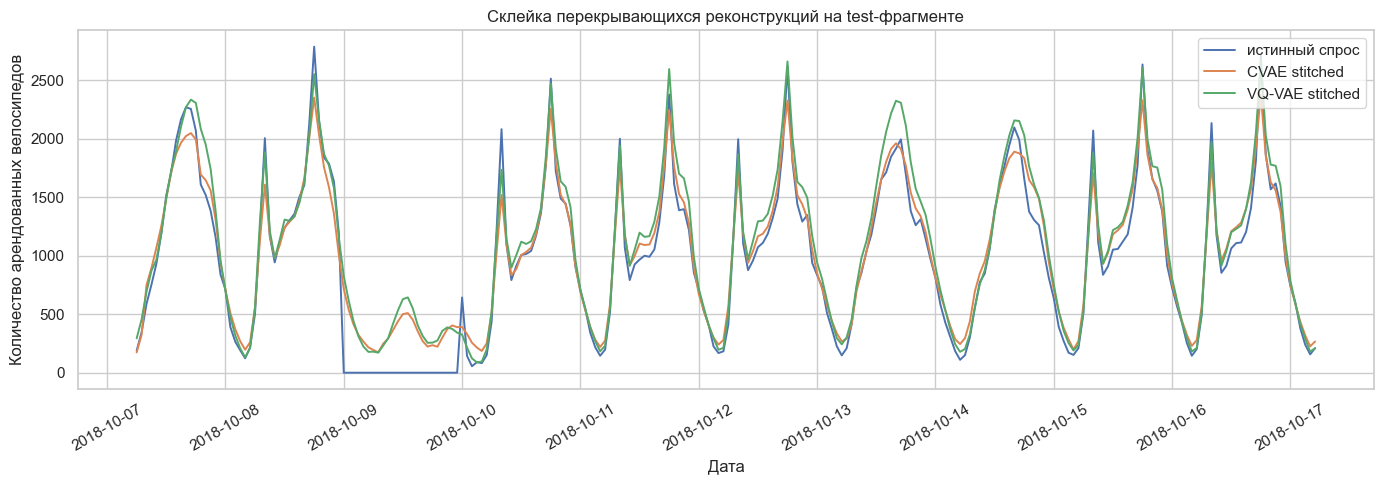

In [177]:
stitched_results = compute_stitched_reconstructions()
display(stitched_results["metrics"])

fragment_len = min(CONFIG["plots"]["fragment_len"], len(X_test))
plot_dates = pd.to_datetime(dates_test[:fragment_len])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_dates, stitched_results["original"][:fragment_len], label="истинный спрос", linewidth=1.4)
ax.plot(plot_dates, stitched_results["cvae"][:fragment_len], label="CVAE stitched", linewidth=1.4)
ax.plot(plot_dates, stitched_results["vqvae"][:fragment_len], label="VQ-VAE stitched", linewidth=1.4)
ax.set_title("Склейка перекрывающихся реконструкций на test-фрагменте")
ax.set_xlabel("Дата")
ax.set_ylabel("Количество арендованных велосипедов")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Склейка перекрывающихся окон показывает качество реконструкции уже на уровне непрерывного test-фрагмента. Это важнее простой конкатенации, потому что один timestamp получает несколько независимых предсказаний. Stitched-метрики поэтому ближе к практическому восприятию восстановленного ряда, чем метрики по отдельным окнам

## Финальное сравнение

Финальное сравнение должно учитывать не только MSE/MAE/R2. CVAE дает непрерывное латентное пространство, prior samples и интерполяцию. VQ-VAE дает дискретные коды, которые можно считать и связывать с типичными формами окон спроса.

In [178]:
# выравниваем названия моделей для объединения оконных и stitched-метрик
stitched_for_merge = stitched_results["metrics"].copy()
stitched_for_merge["Model"] = stitched_for_merge["Model"].str.replace(" stitched", "", regex=False)

final_comparison = comparison_df.merge(
    stitched_for_merge.rename(columns={
        "MSE": "stitched_MSE",
        "MAE": "stitched_MAE",
        "R2": "stitched_R2",
    }),
    left_on="Model",
    right_on="Model",
    how="left",
)

display(final_comparison)

,Model,MSE,MAE,R2,stitched_MSE,stitched_MAE,stitched_R2
0,Conditional VAE,39753.707031,152.157562,0.877184,24387.246094,119.500420,0.924846
1,Conditional VQ-VAE,61753.460938,183.433609,0.809217,38296.476562,144.842789,0.881982


Финальное сравнение стоит читать по двум осям: численная ошибка показывает точность реконструкции, а тип латентного пространства определяет, что можно анализировать после обучения — непрерывные интерполяции у CVAE или дискретные режимы у VQ-VAE